In [73]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense, LSTM
import warnings
warnings.filterwarnings('ignore')

In [74]:
plt.style.use('fivethirtyeight')
cryptos = ['BTC-USD', 'ETH-USD', 'SOL-USD', 'DOGE-USD', 'BNB-USD', 'ADA-USD', 'XRP-USD',
           'DOT-USD', 'AVAX-USD', 'SHIB-USD', 'TRX-USD', 'MATIC-USD', 'LTC-USD', 'BCH-USD',
           'XLM-USD', 'ATOM-USD', 'HBAR-USD', 'ETC-USD', 'FIL-USD', 'ICP-USD']
           
end = datetime.now()
start = datetime(end.year-5, end.month, end.day)  # 5 years data for efficiency

base_days = 100
future_days = 10


--- BTC-USD ---


[*********************100%***********************]  1 of 1 completed


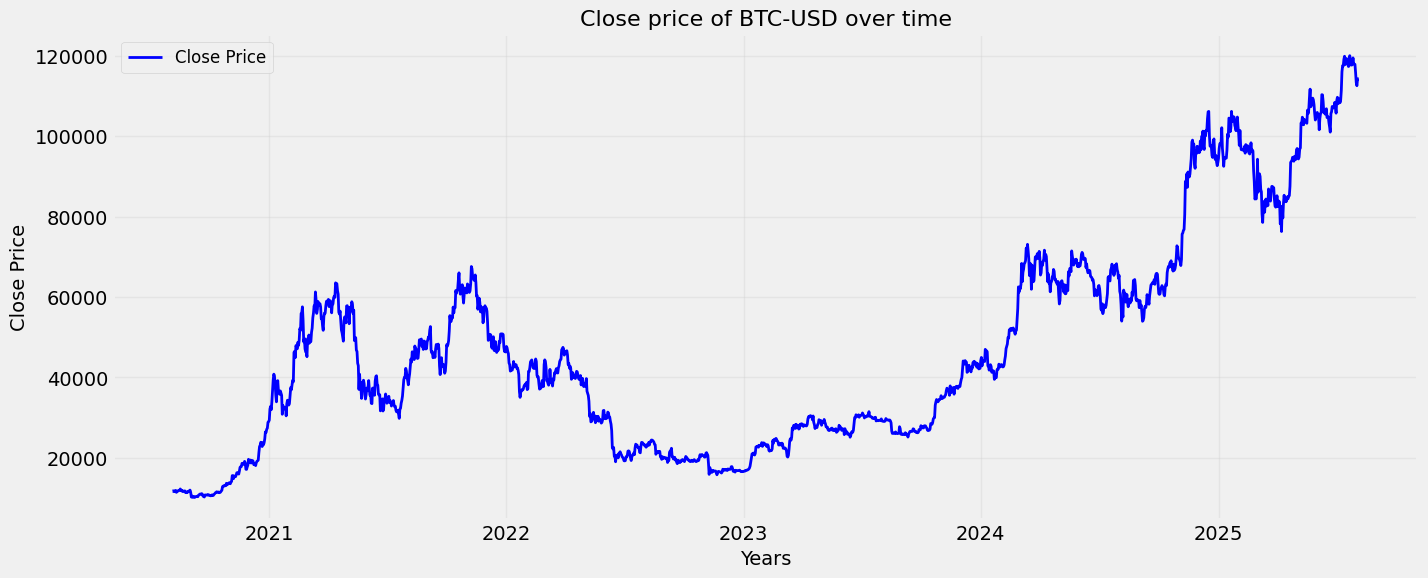

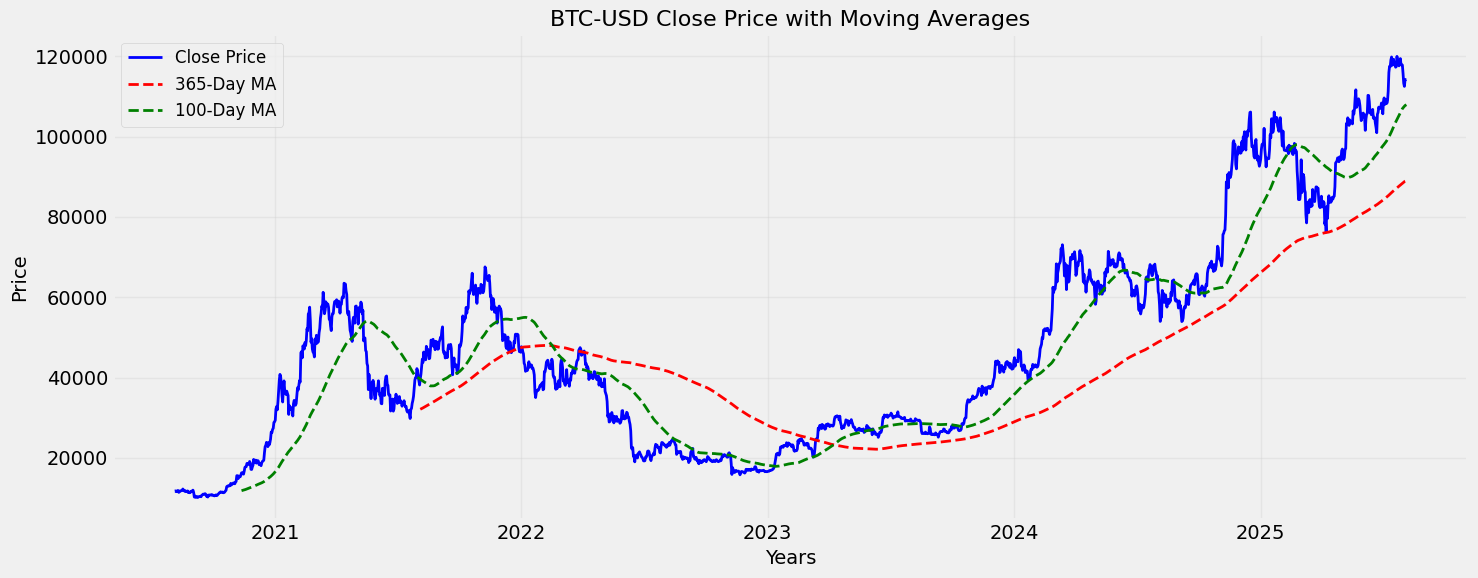

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 97ms/step


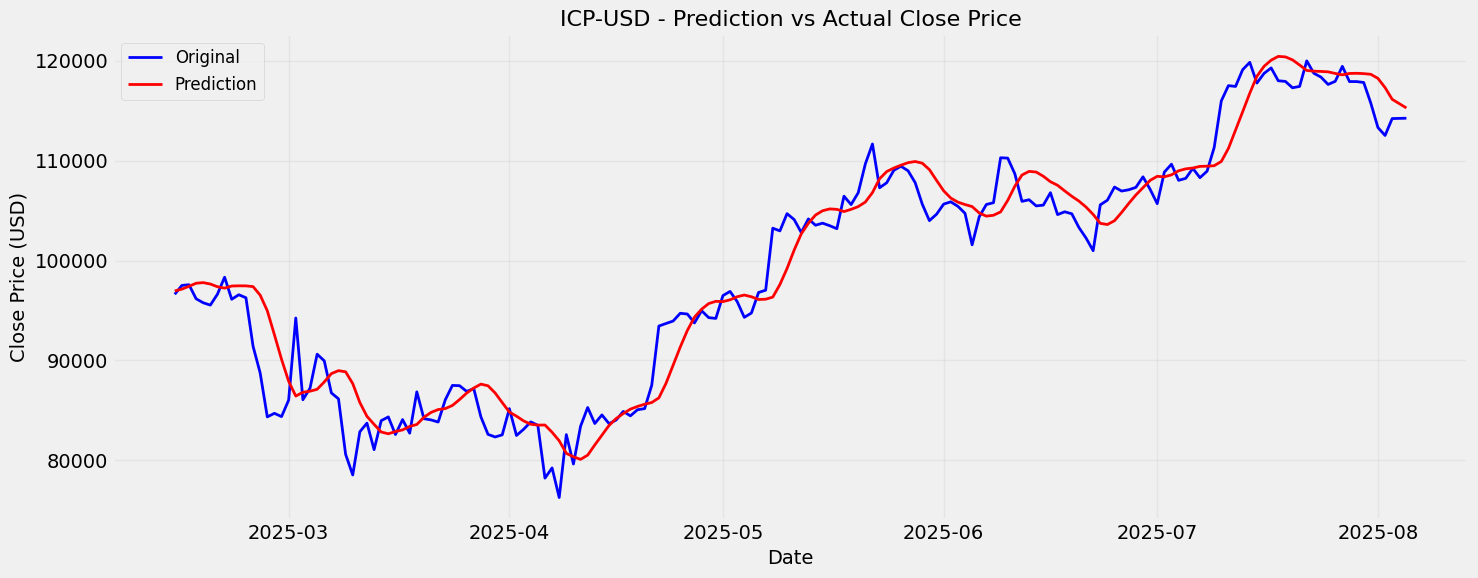


--- ETH-USD ---


[*********************100%***********************]  1 of 1 completed


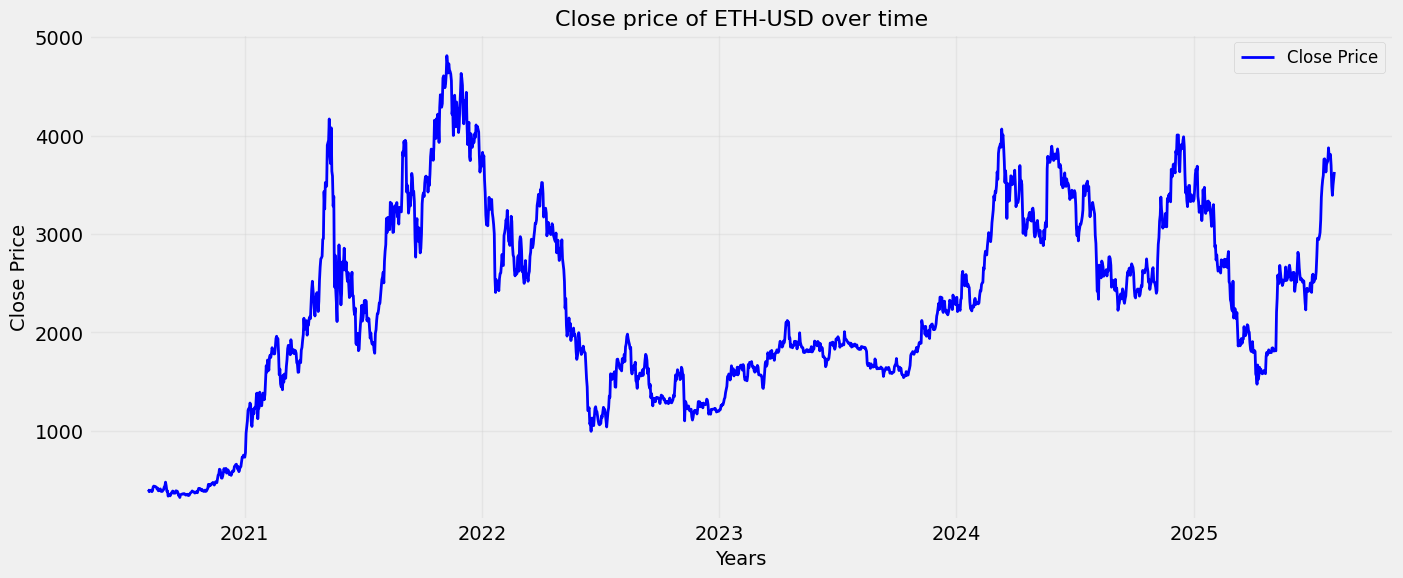

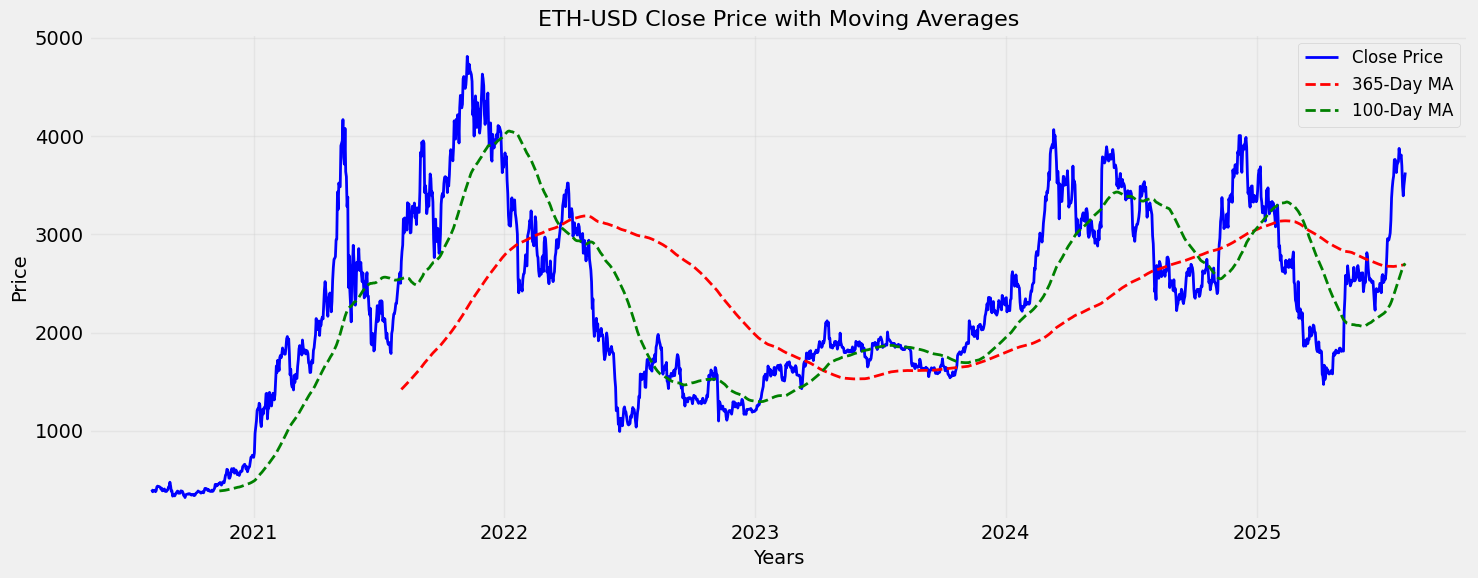

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 102ms/step


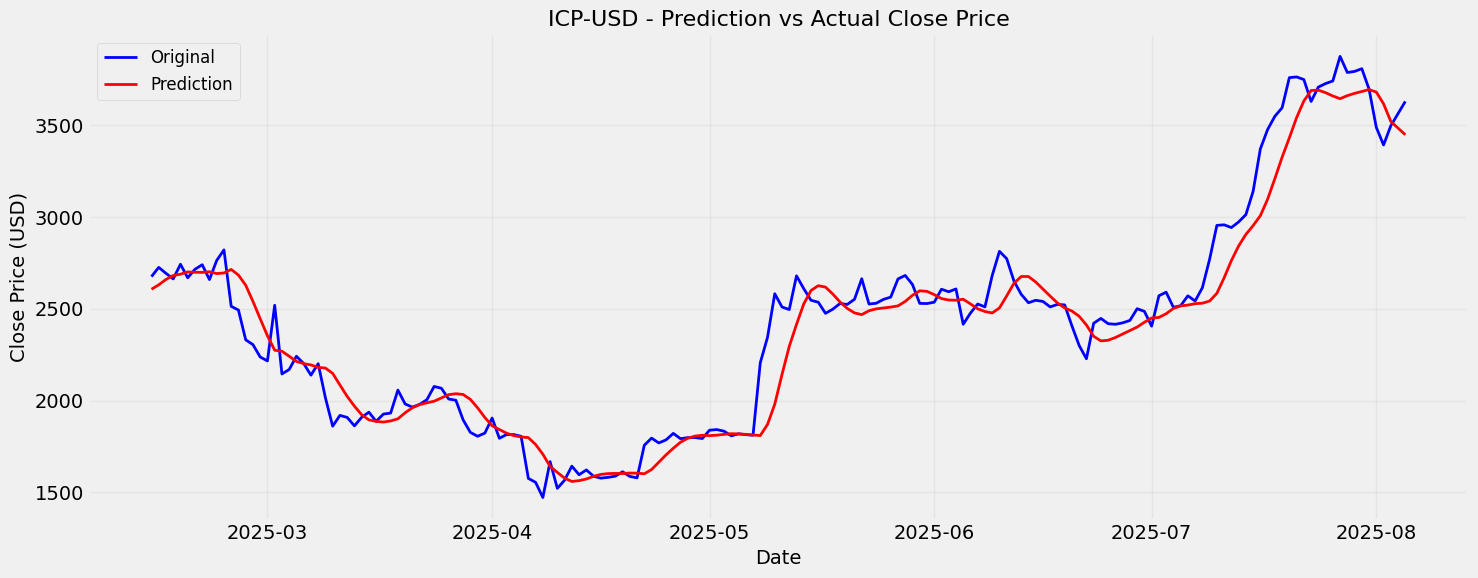


--- SOL-USD ---


[*********************100%***********************]  1 of 1 completed


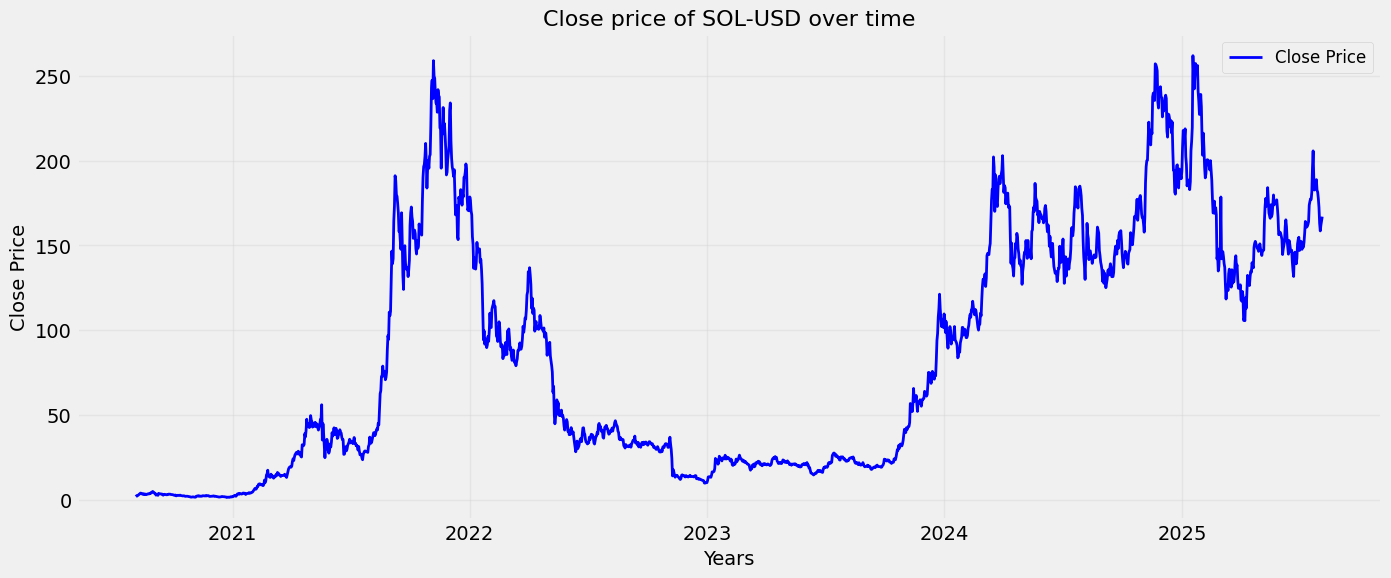

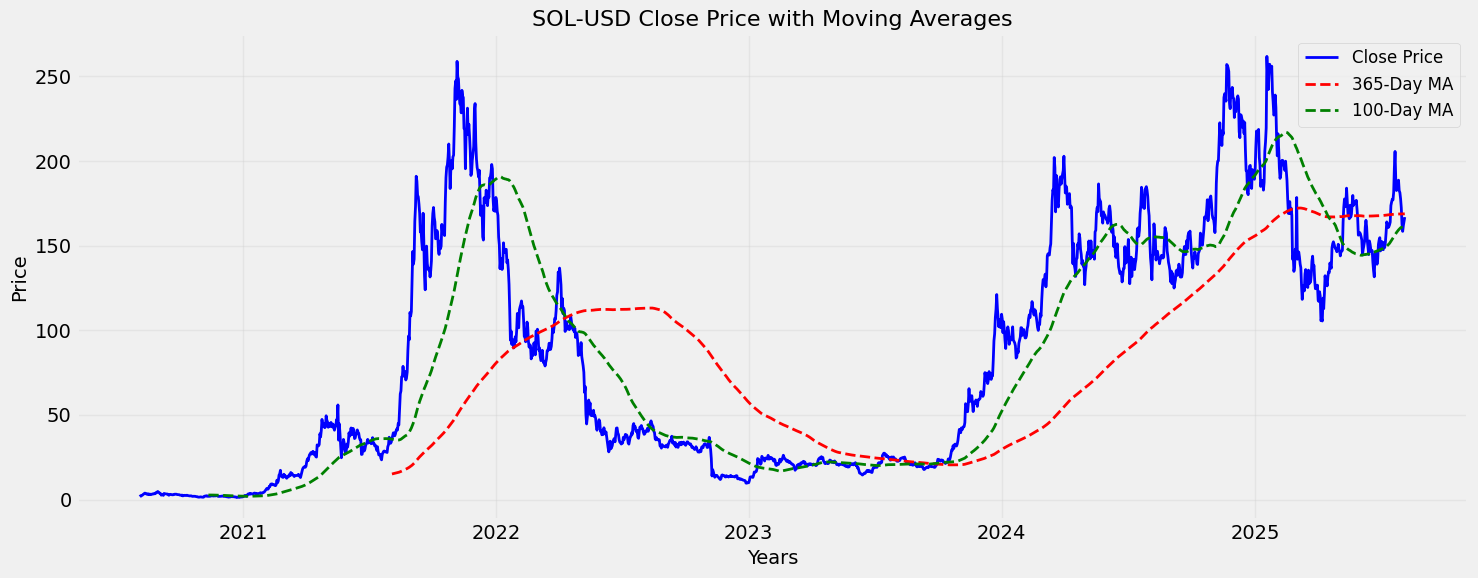

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step


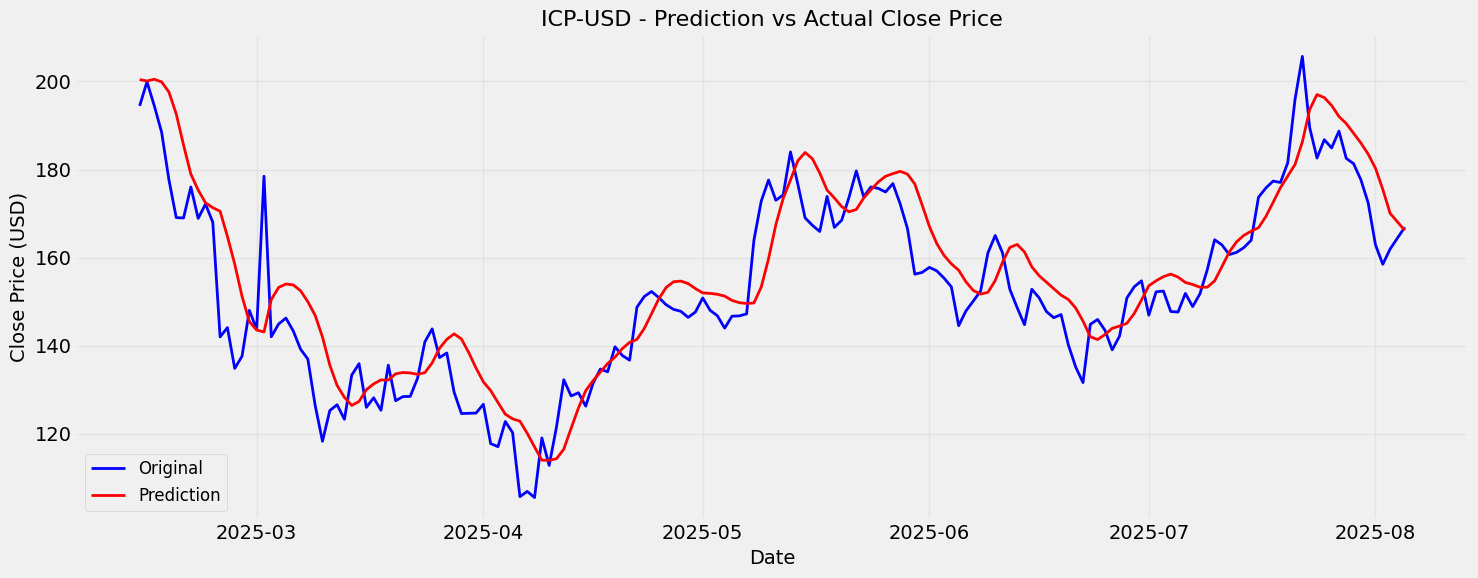


--- DOGE-USD ---


[*********************100%***********************]  1 of 1 completed


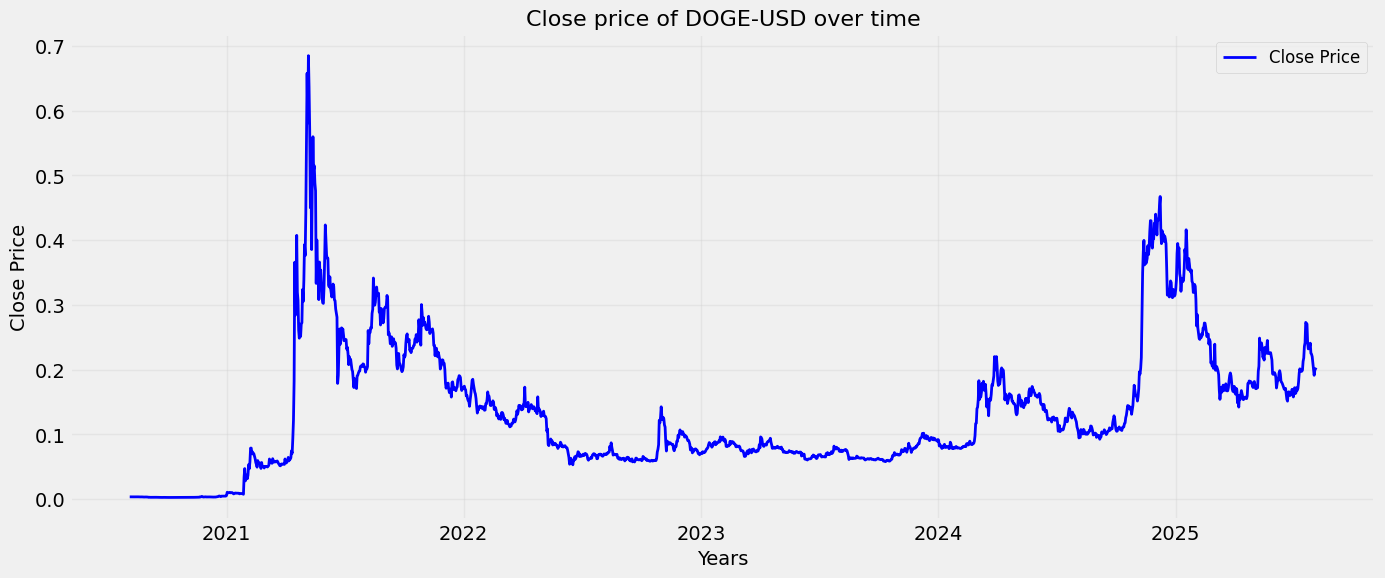

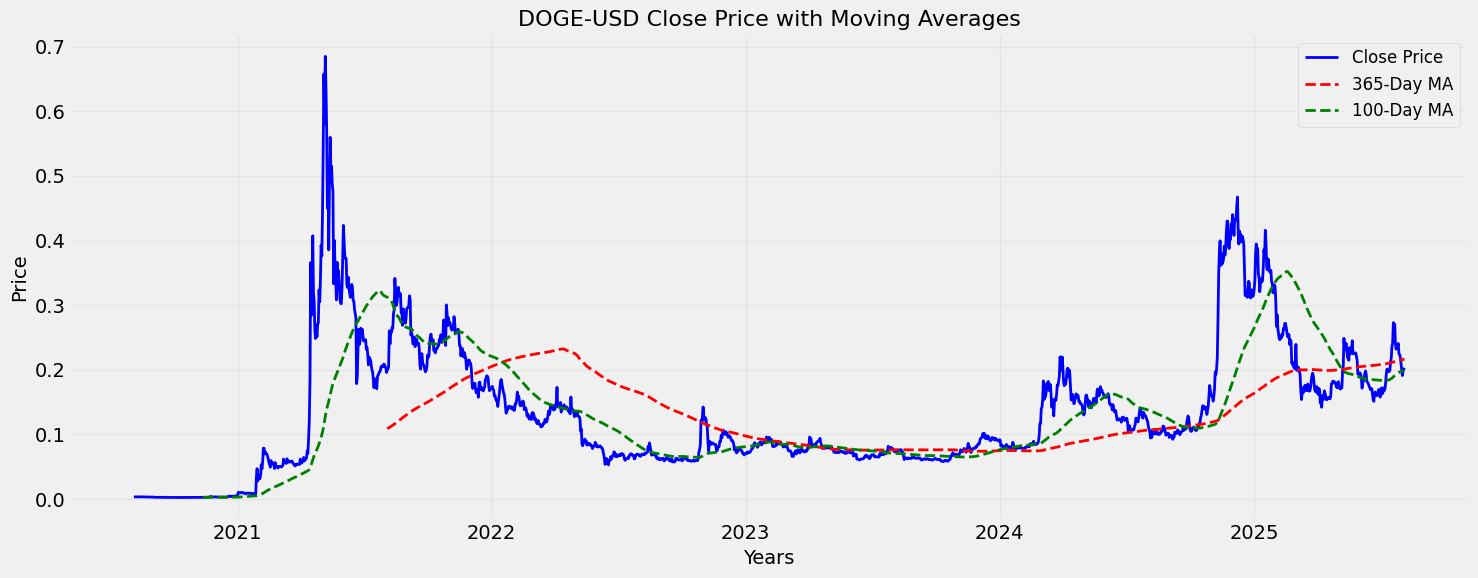

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 109ms/step


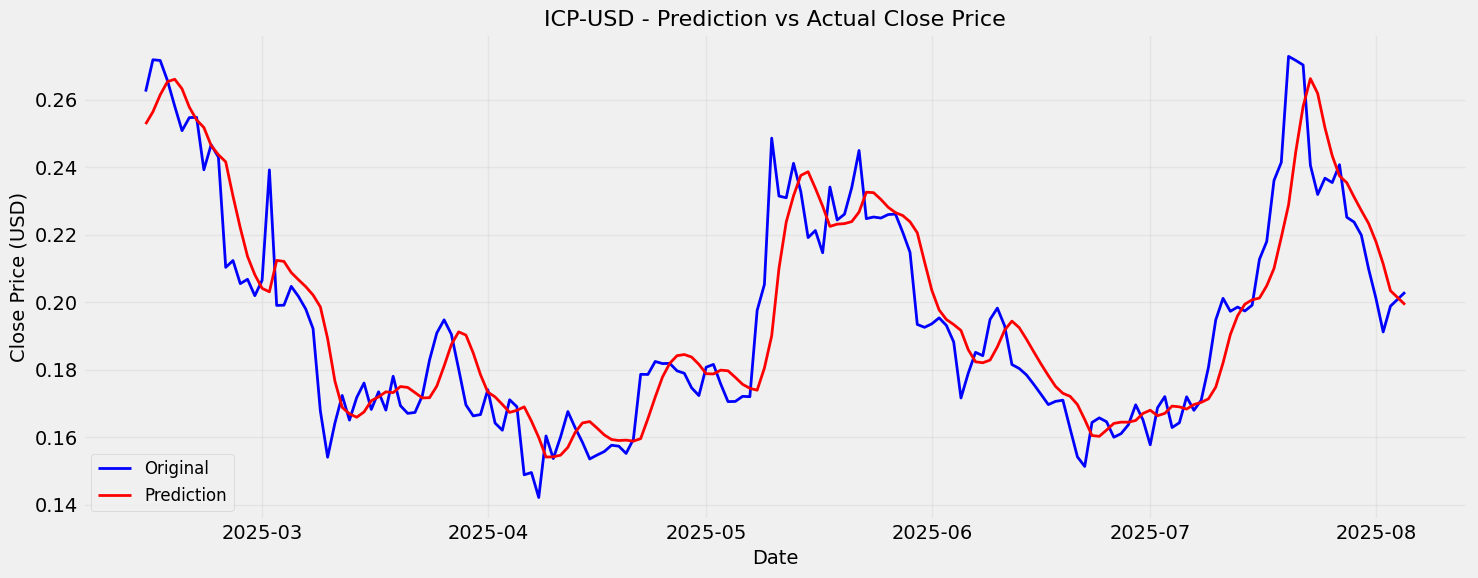


--- BNB-USD ---


[*********************100%***********************]  1 of 1 completed


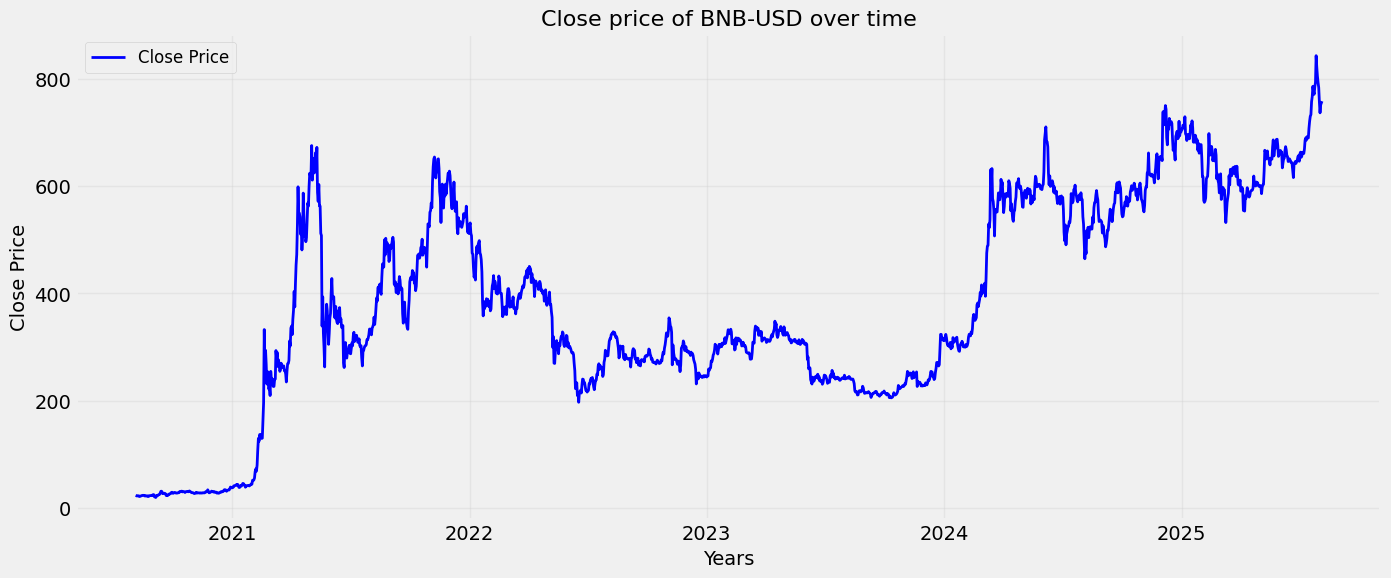

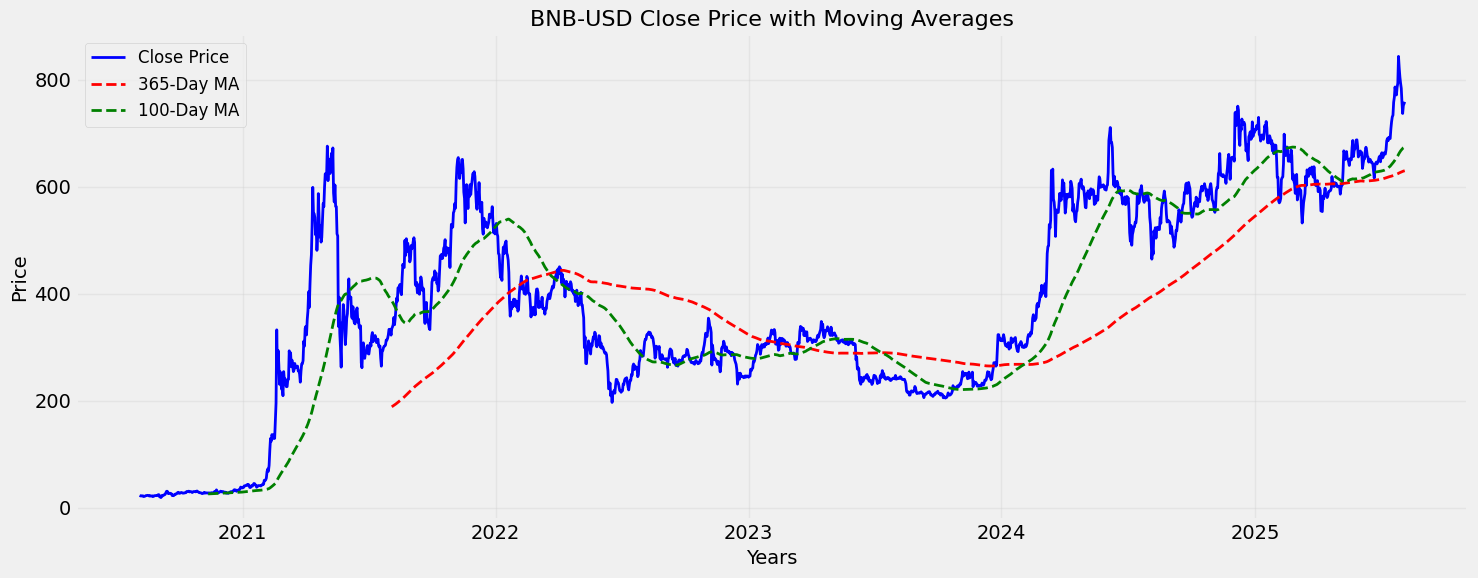

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step


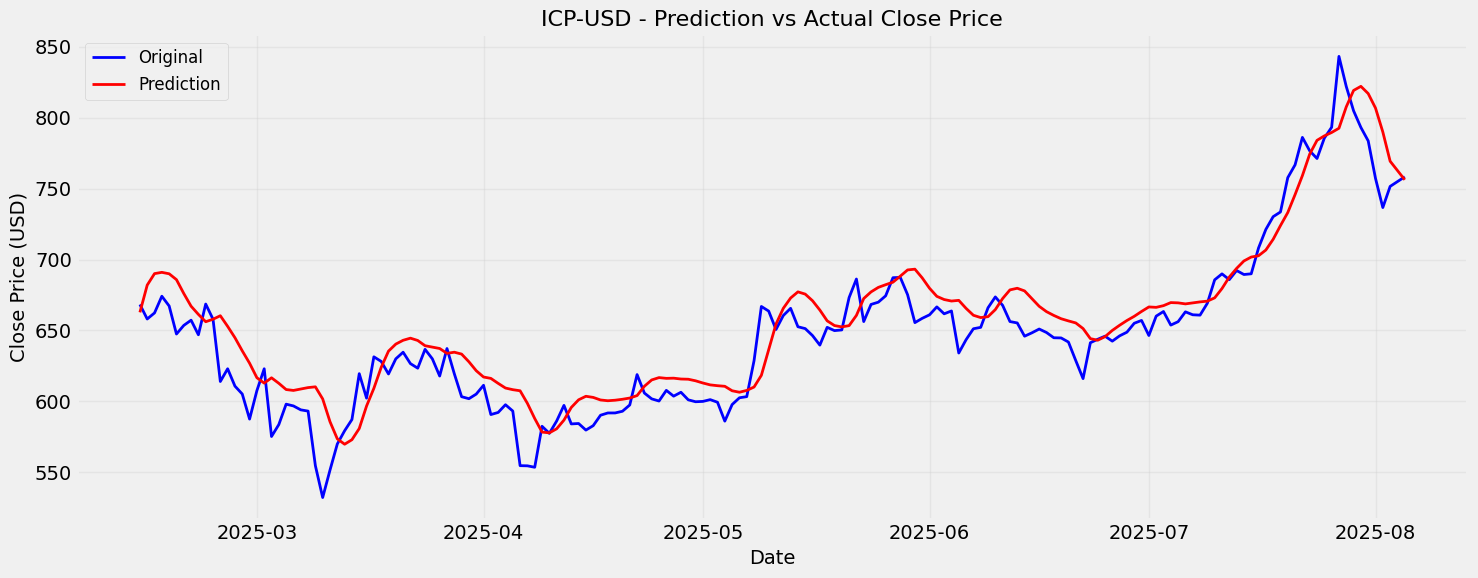


--- ADA-USD ---


[*********************100%***********************]  1 of 1 completed


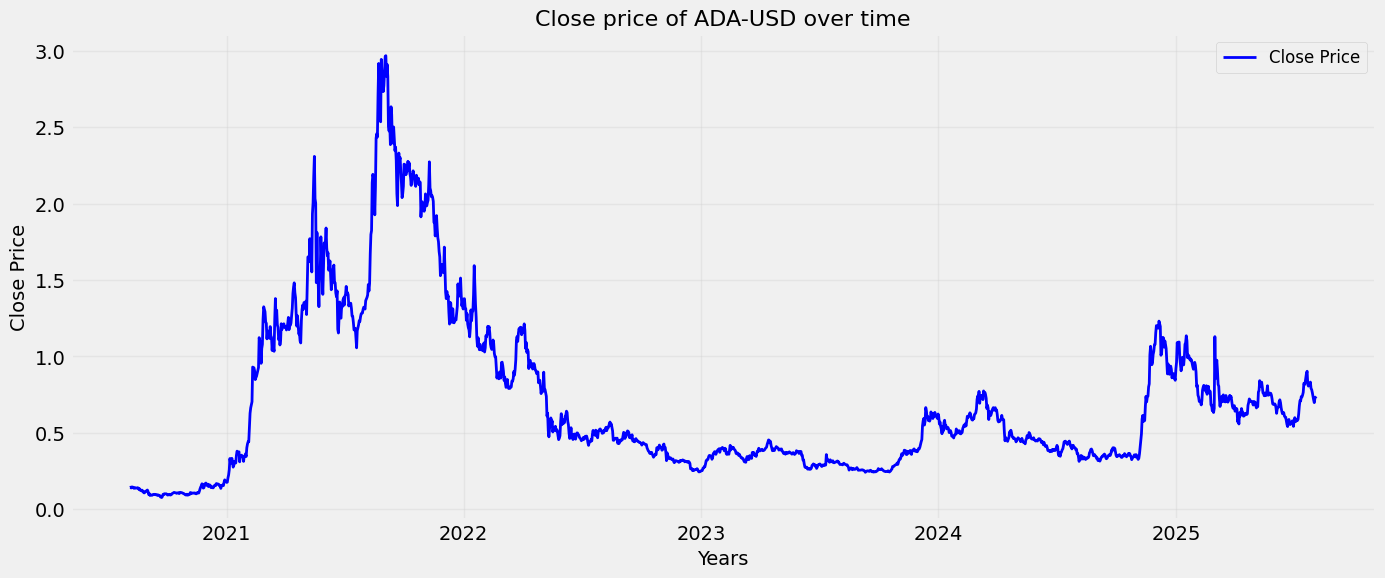

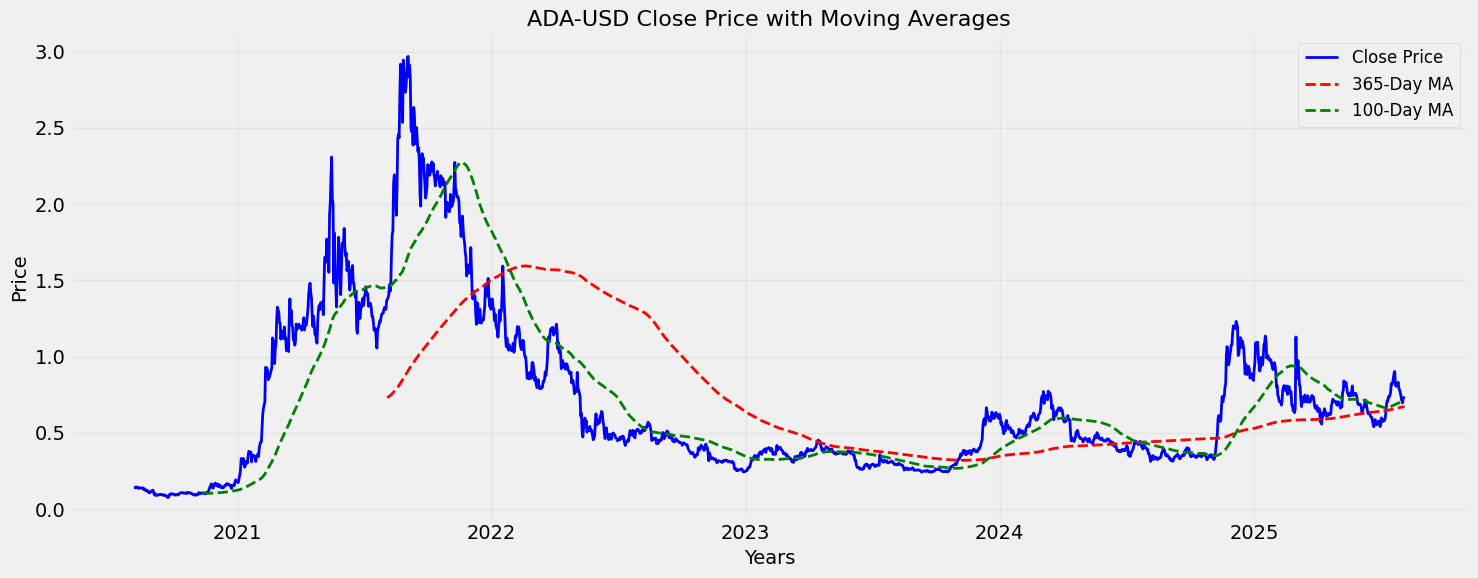

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 102ms/step


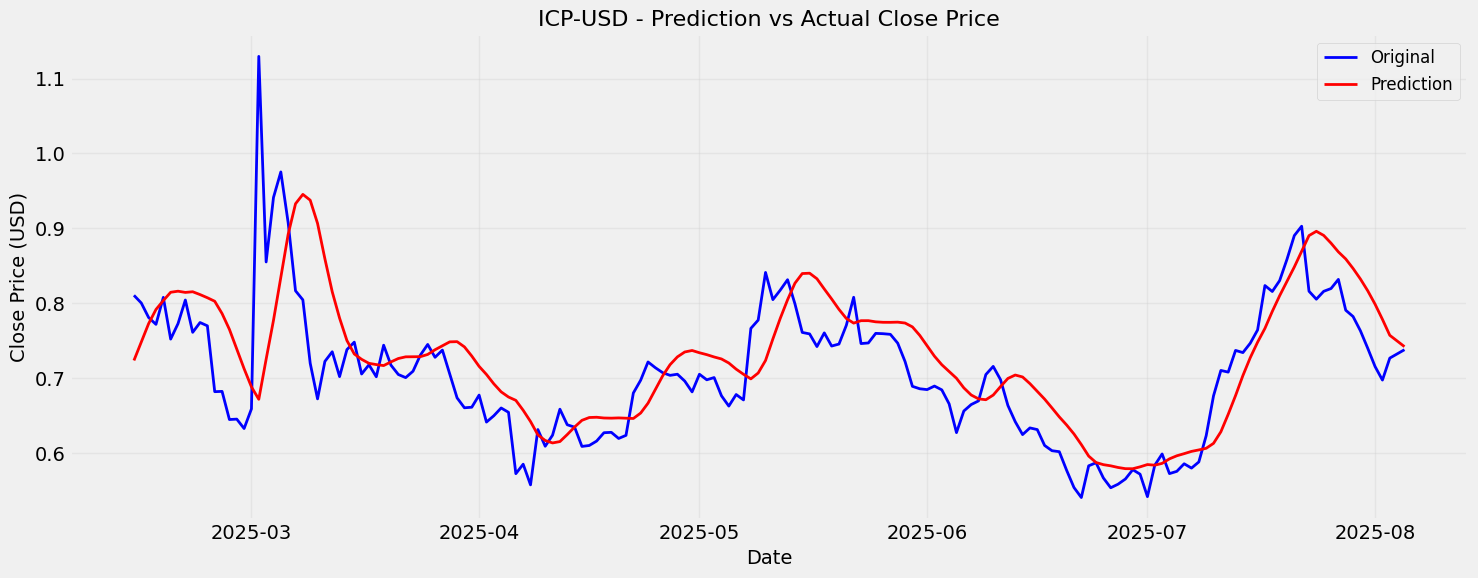


--- XRP-USD ---


[*********************100%***********************]  1 of 1 completed


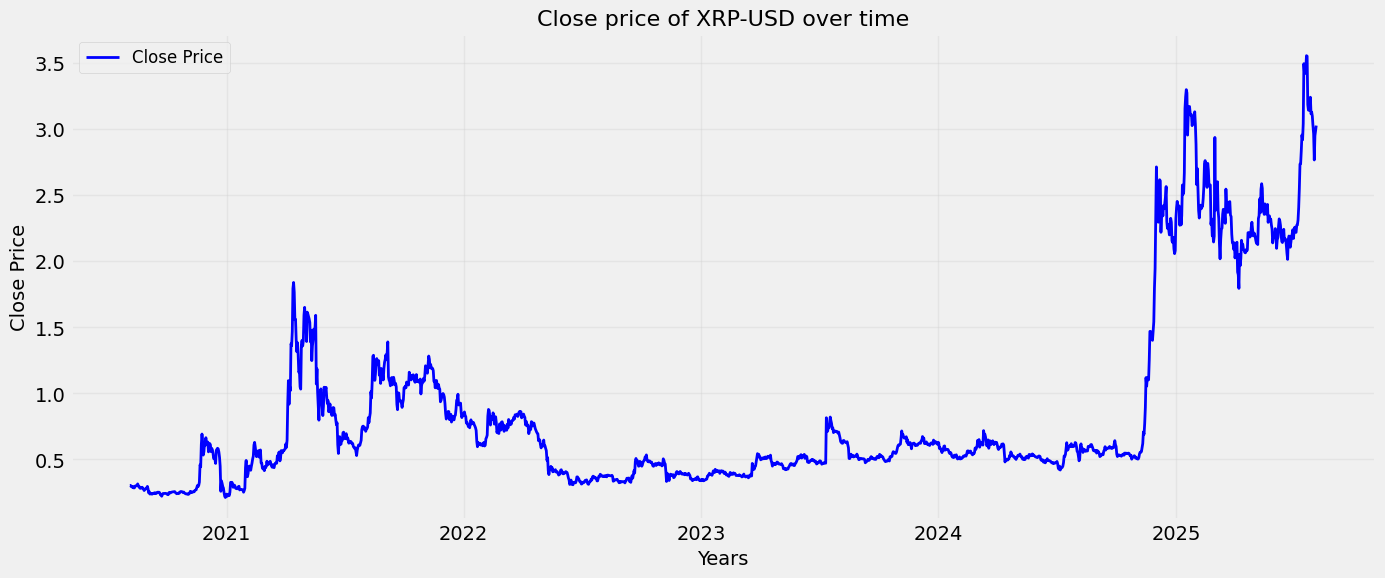

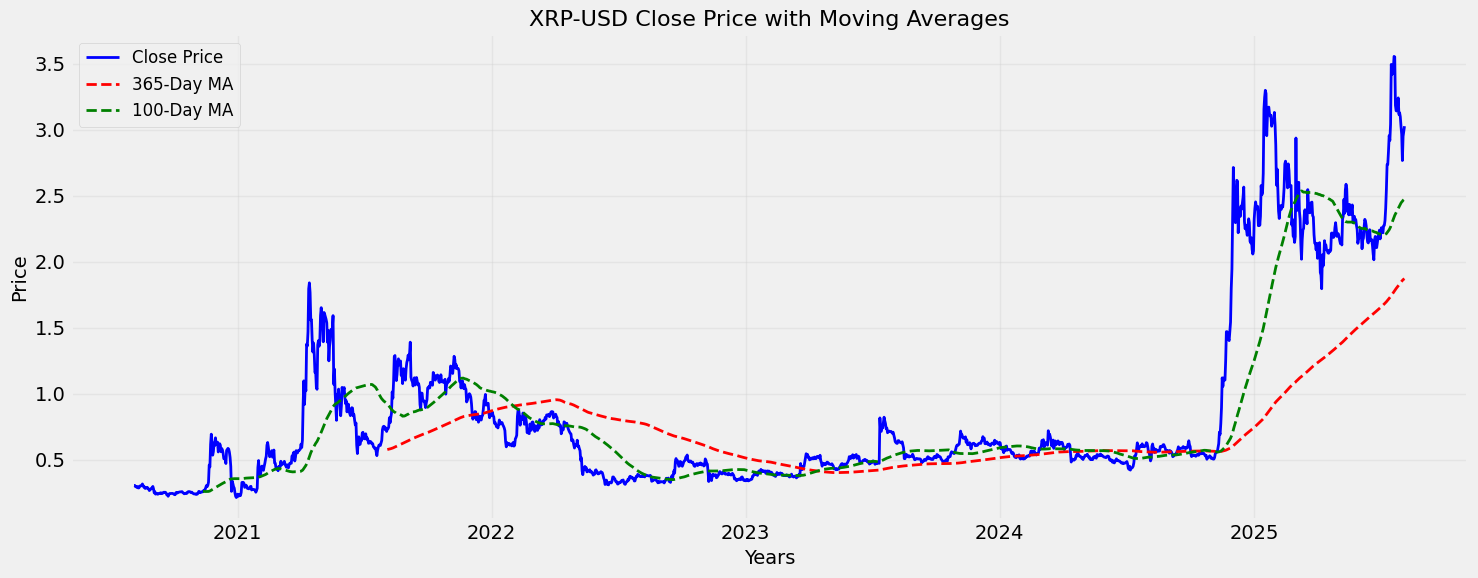

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step


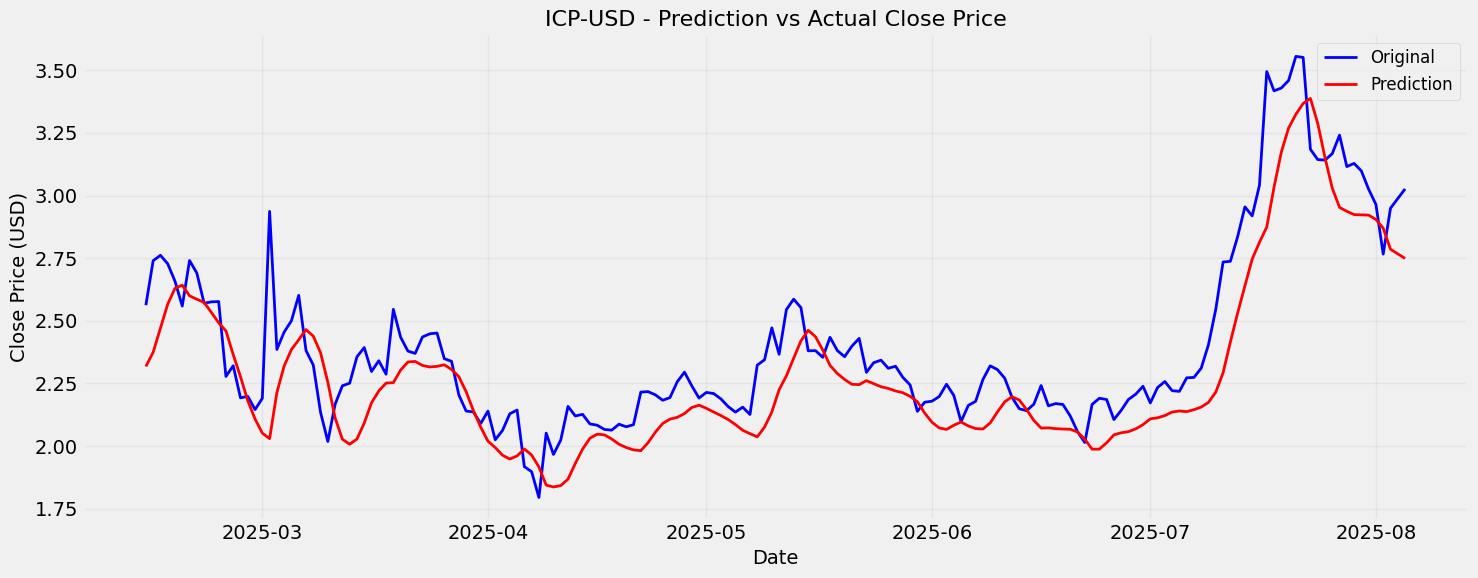


--- DOT-USD ---


[*********************100%***********************]  1 of 1 completed


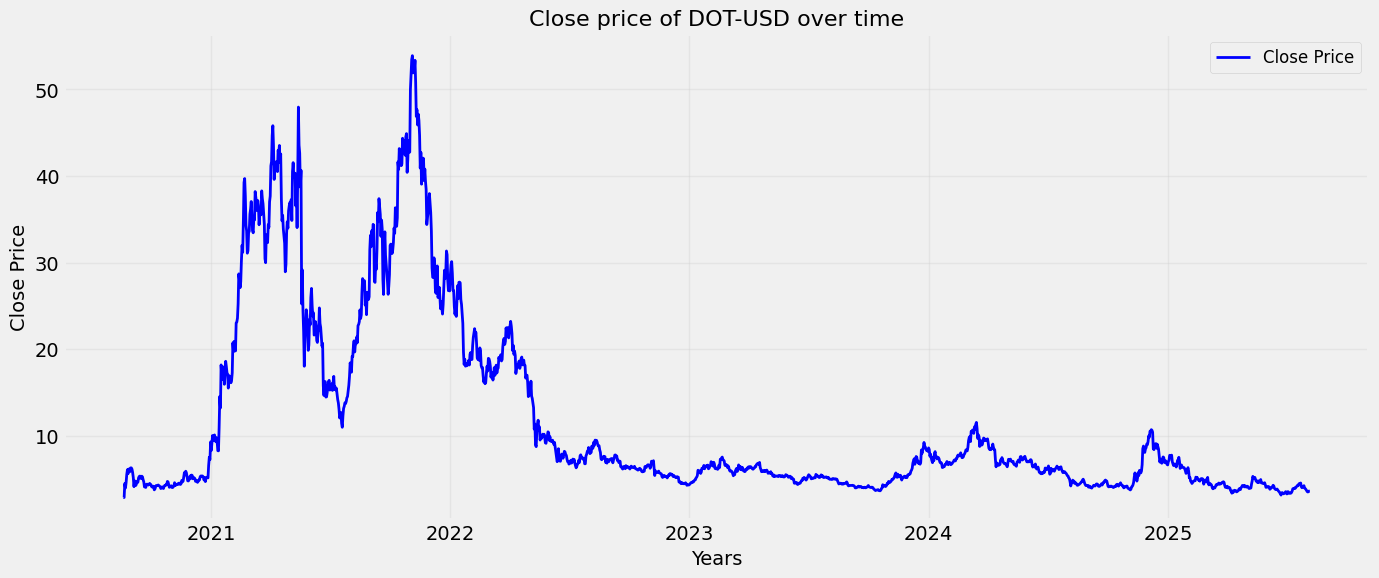

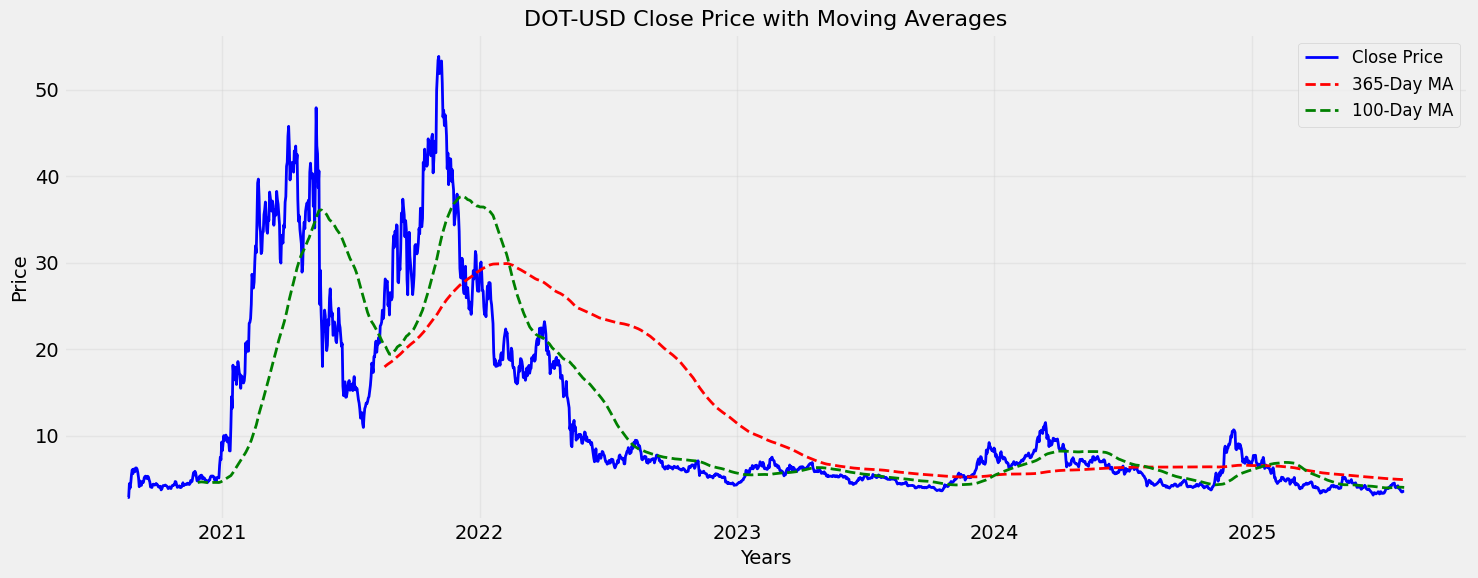

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 90ms/step


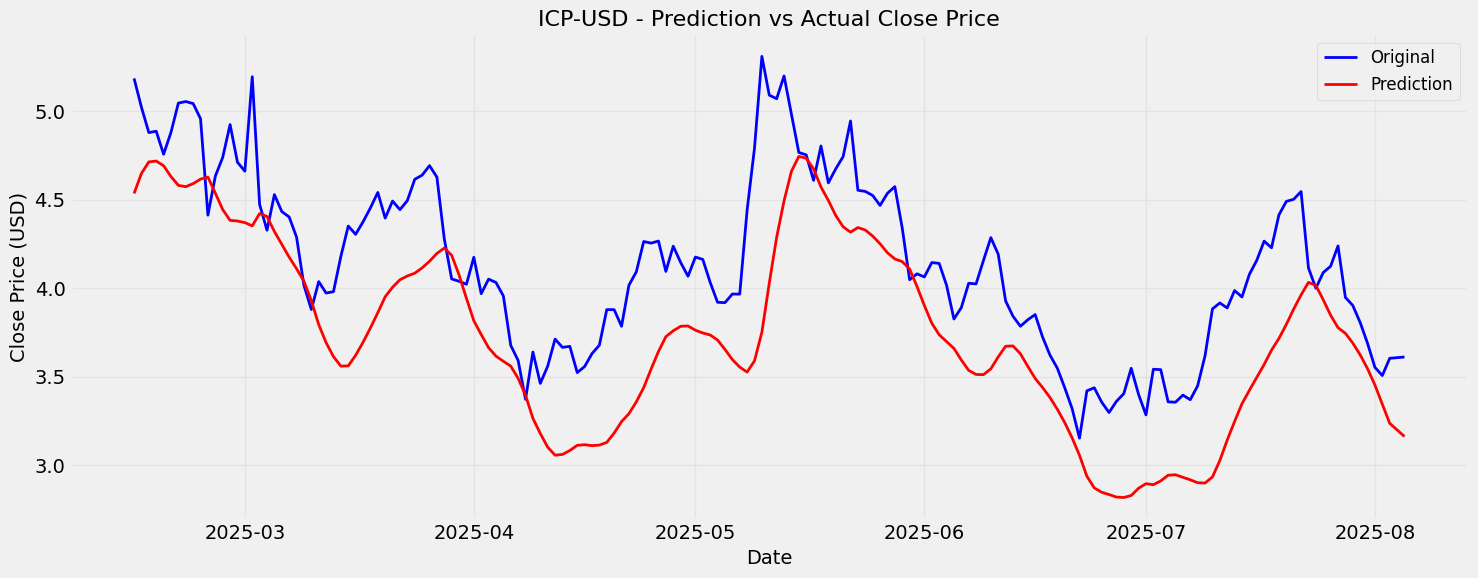


--- AVAX-USD ---


[*********************100%***********************]  1 of 1 completed


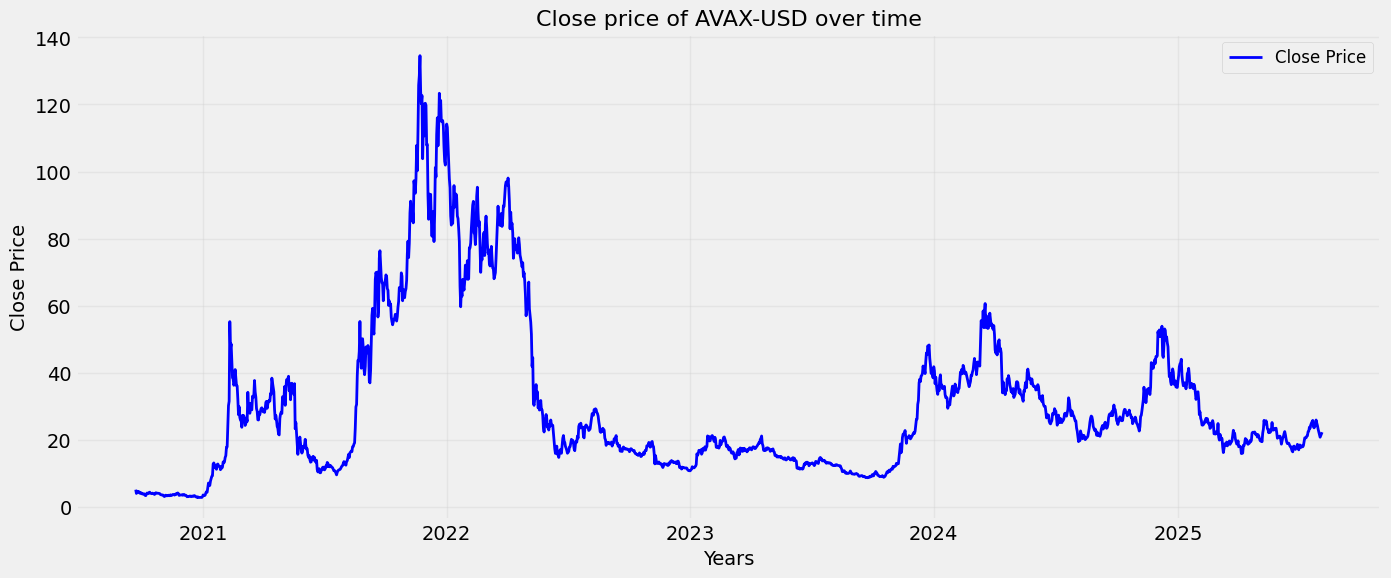

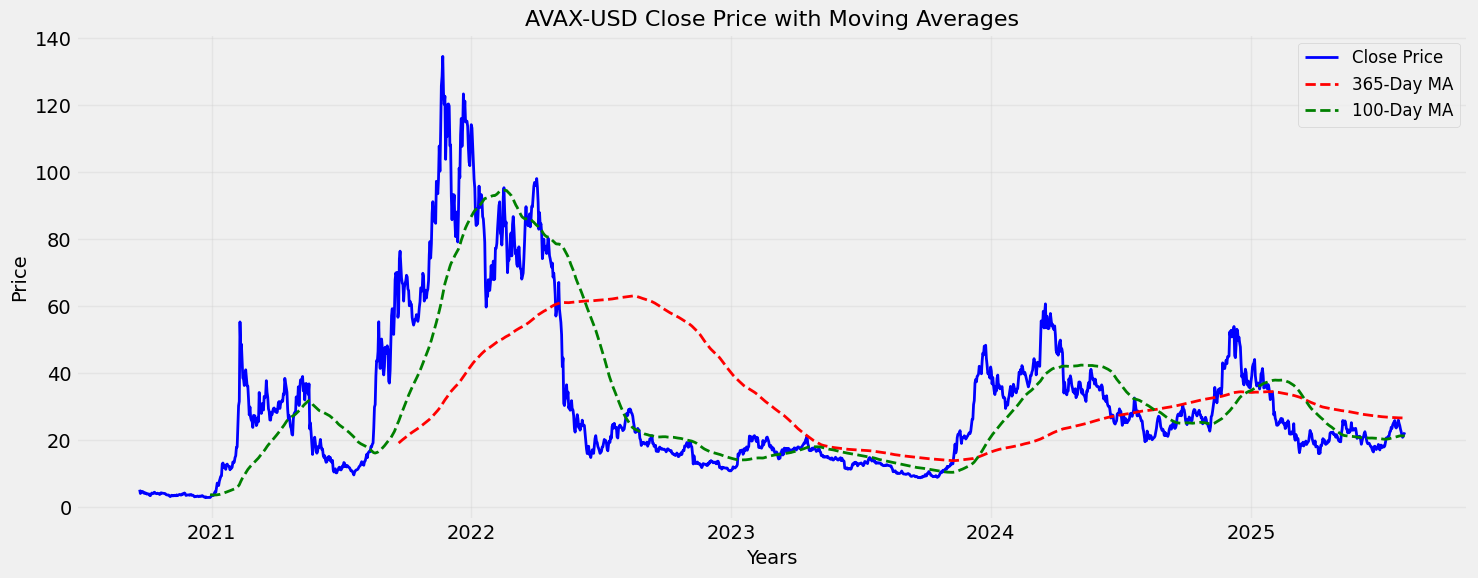

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 110ms/step


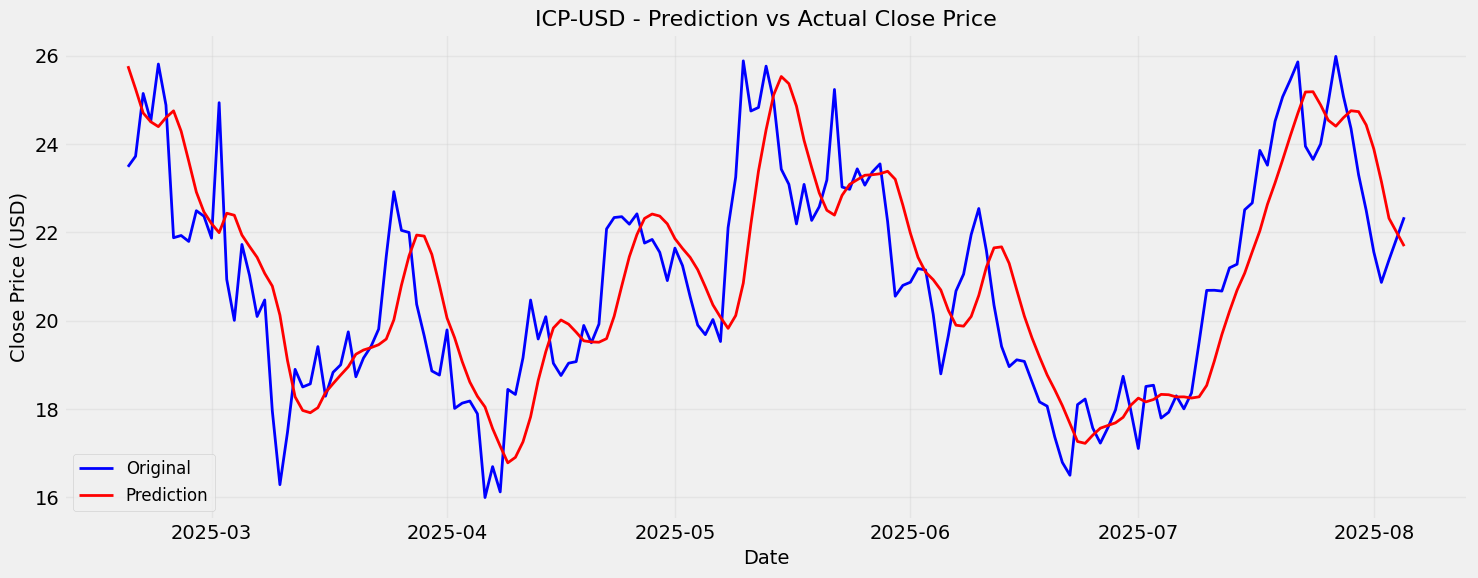


--- SHIB-USD ---


[*********************100%***********************]  1 of 1 completed


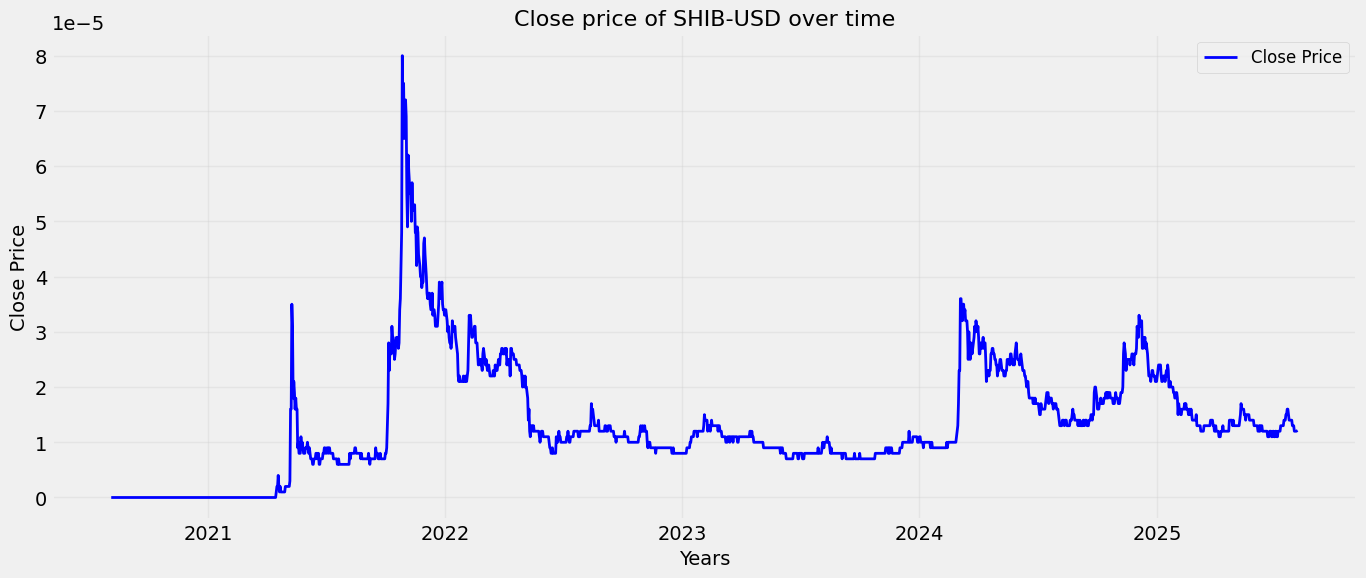

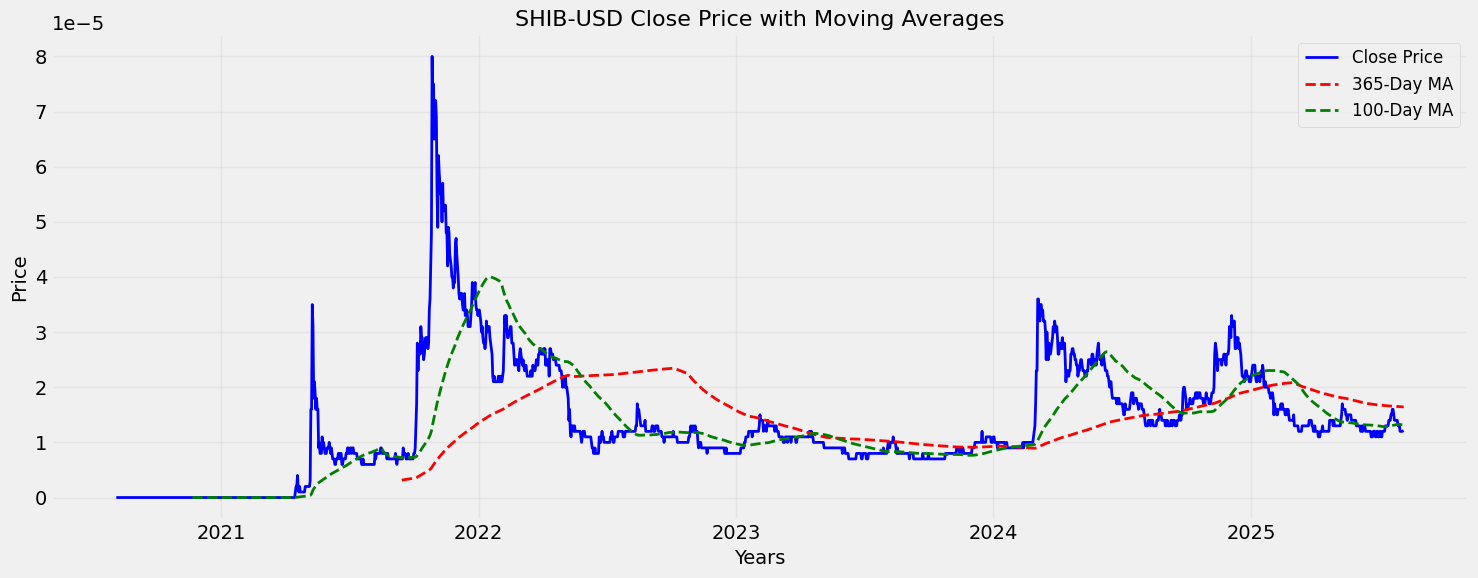

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 100ms/step


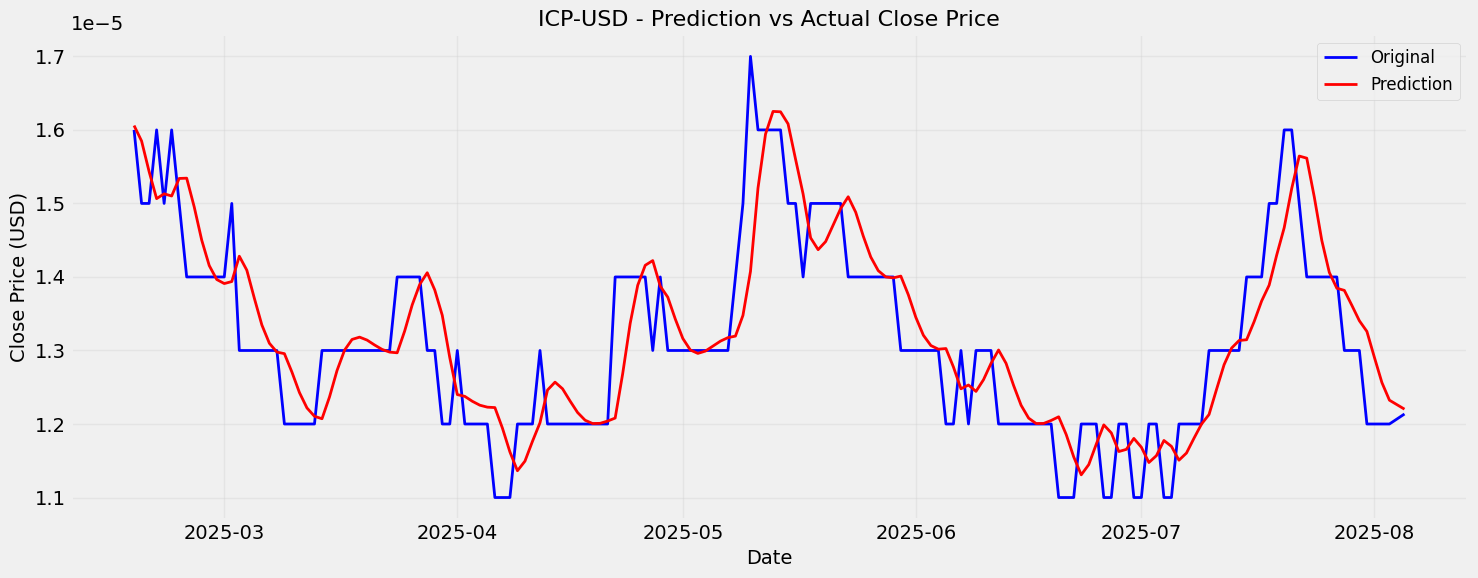


--- TRX-USD ---


[*********************100%***********************]  1 of 1 completed


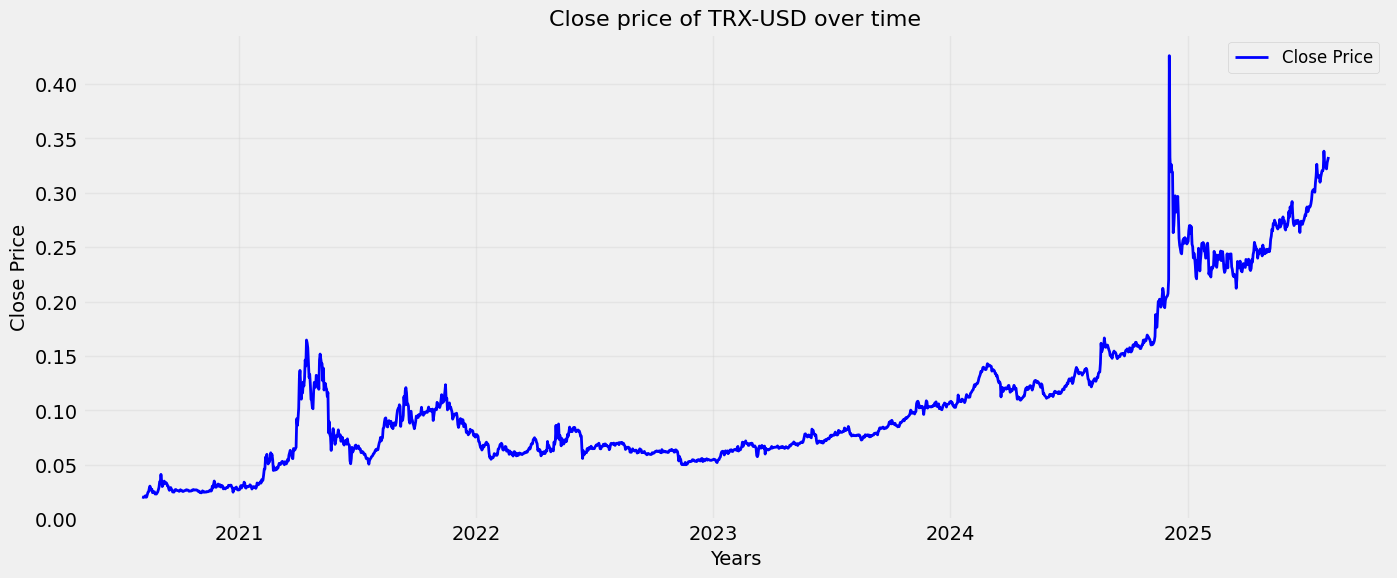

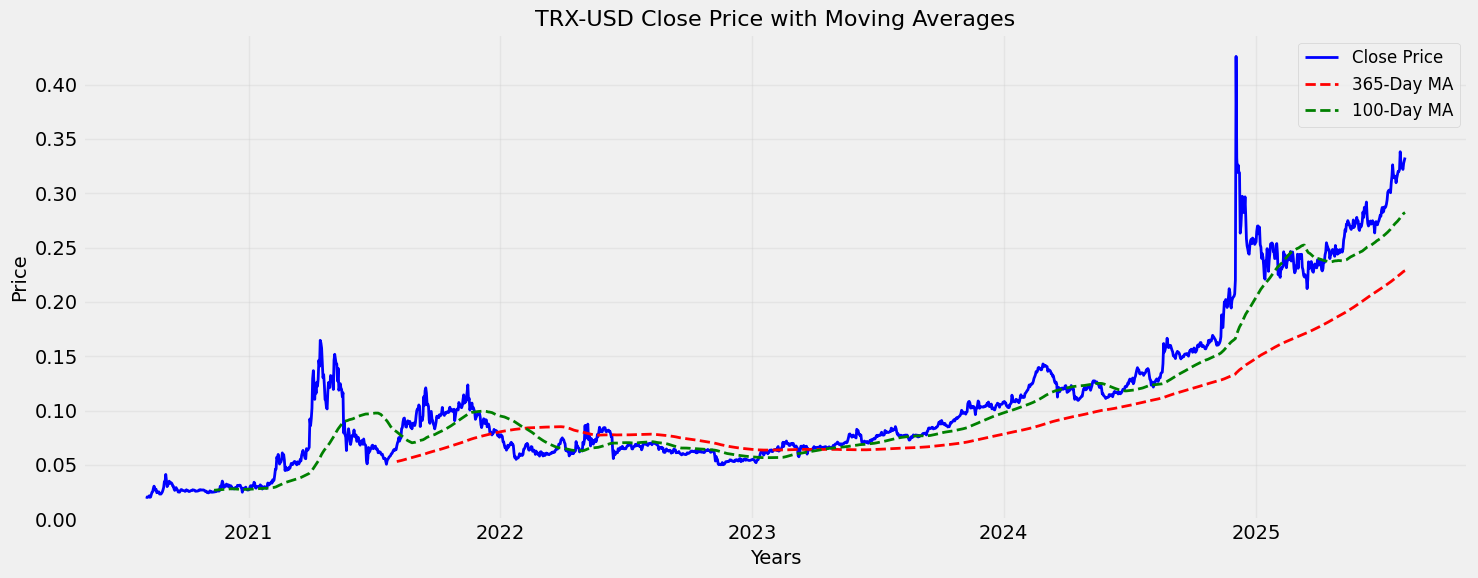

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 151ms/step


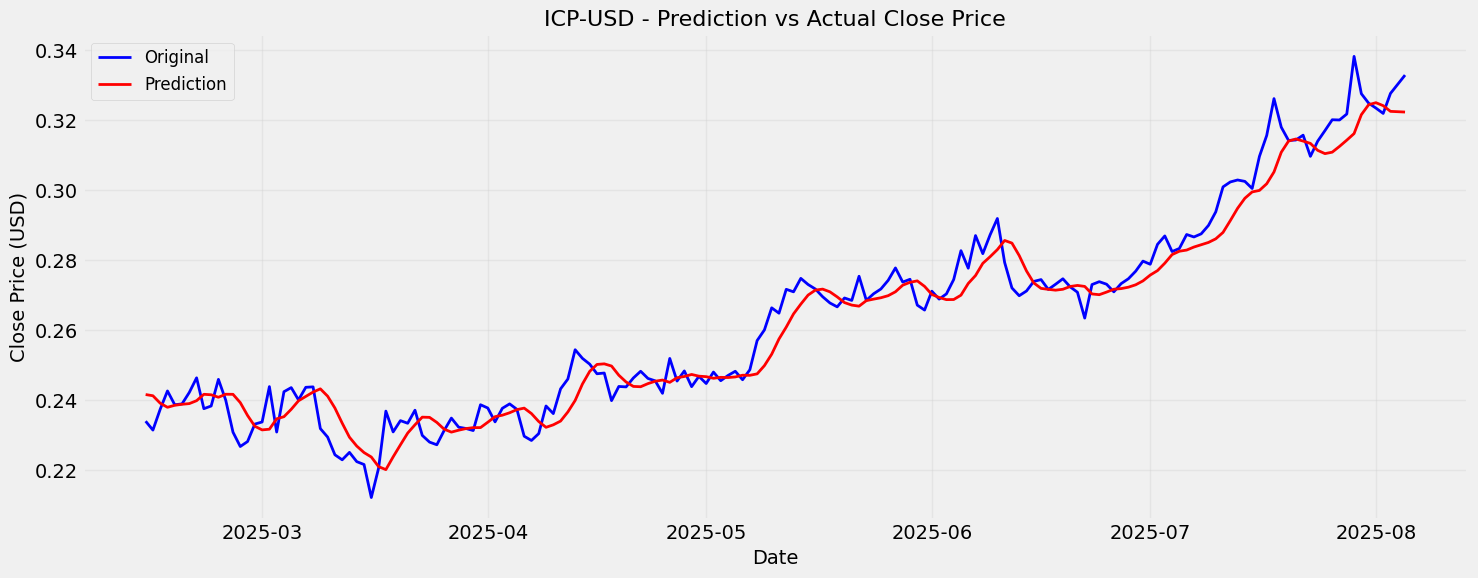


--- MATIC-USD ---


[*********************100%***********************]  1 of 1 completed


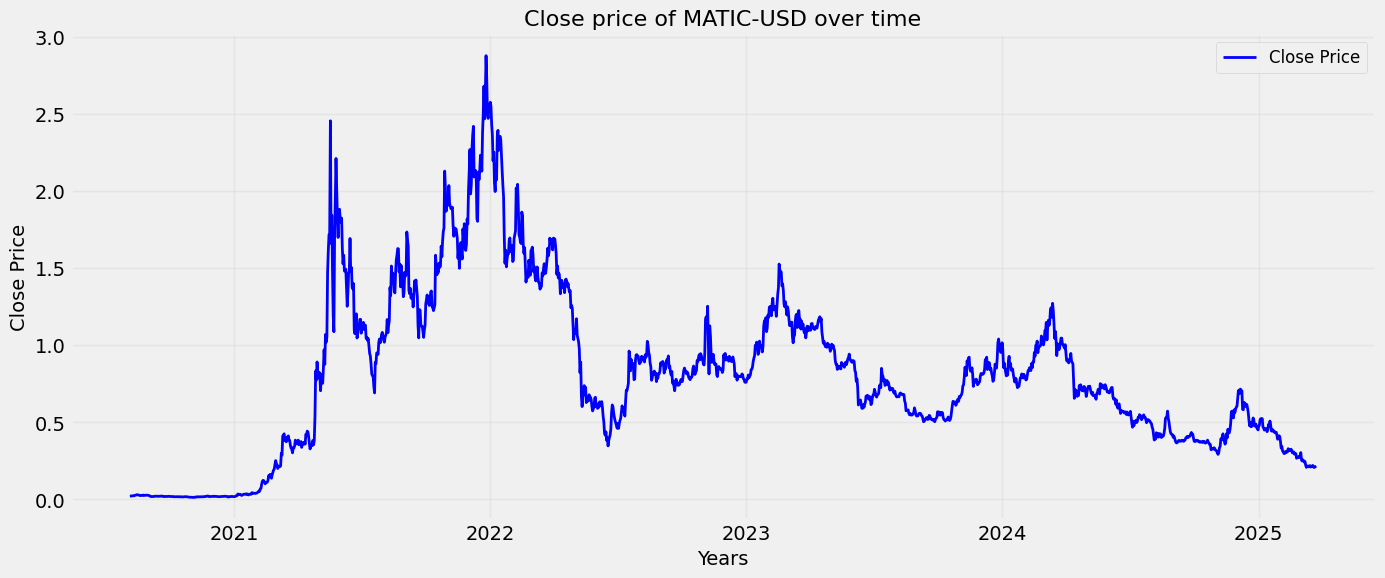

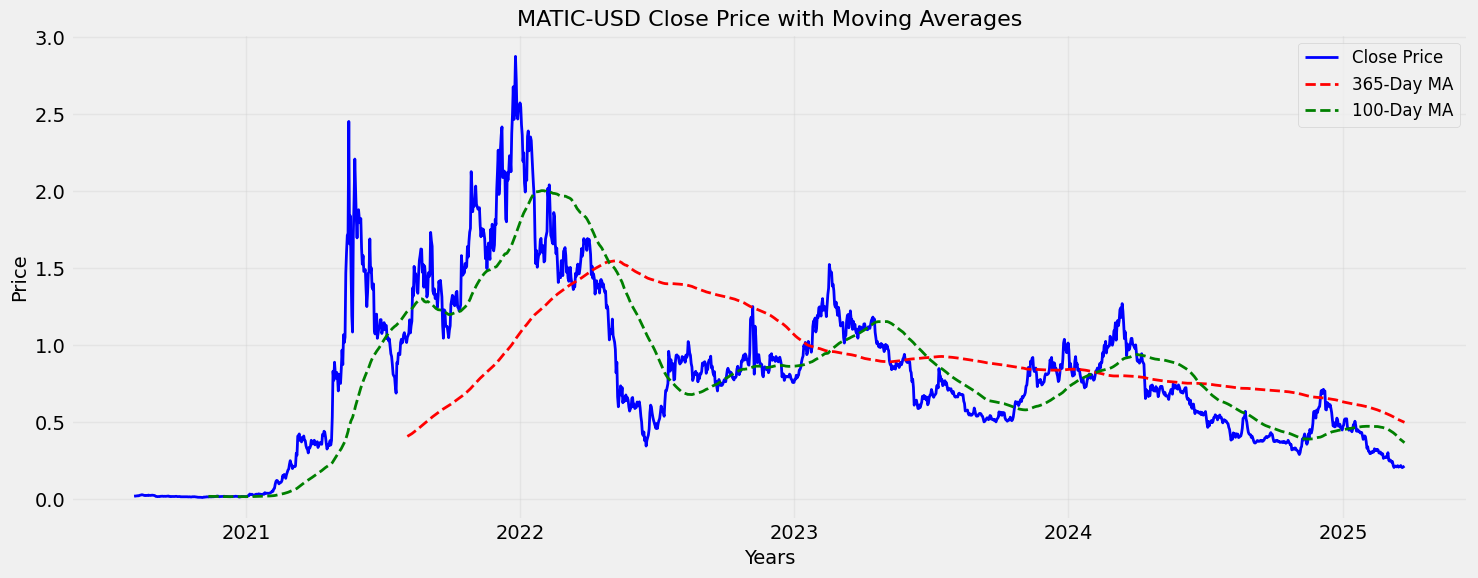

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step


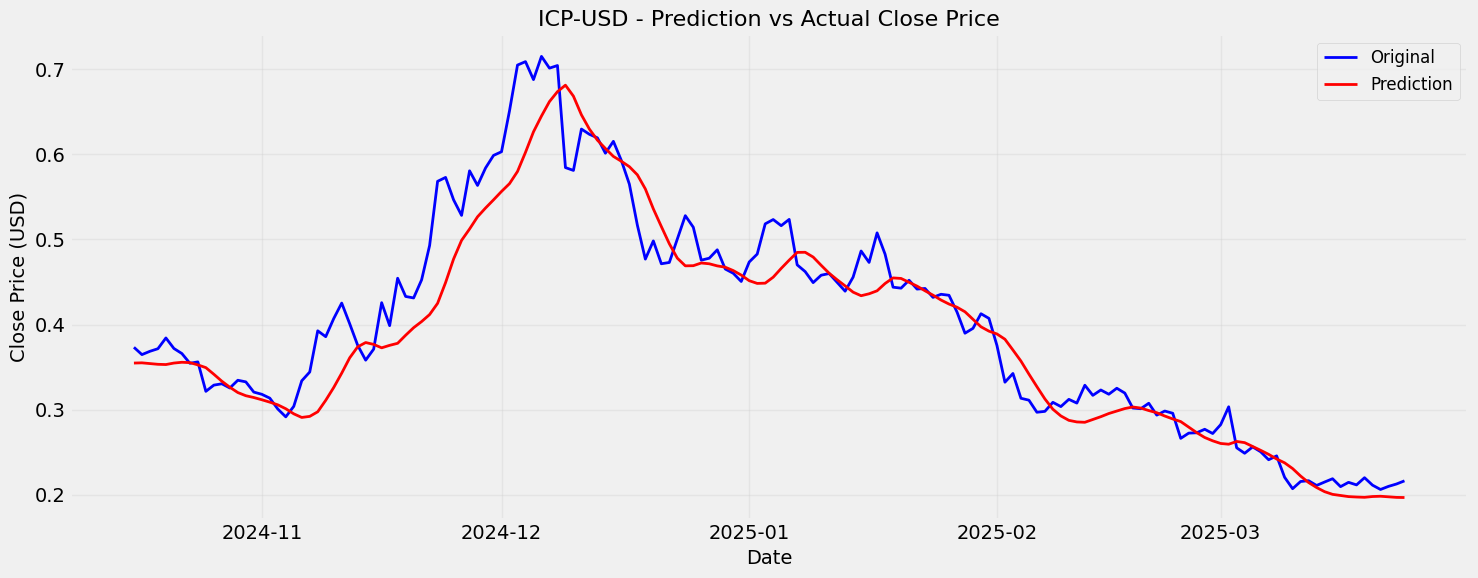


--- LTC-USD ---


[*********************100%***********************]  1 of 1 completed


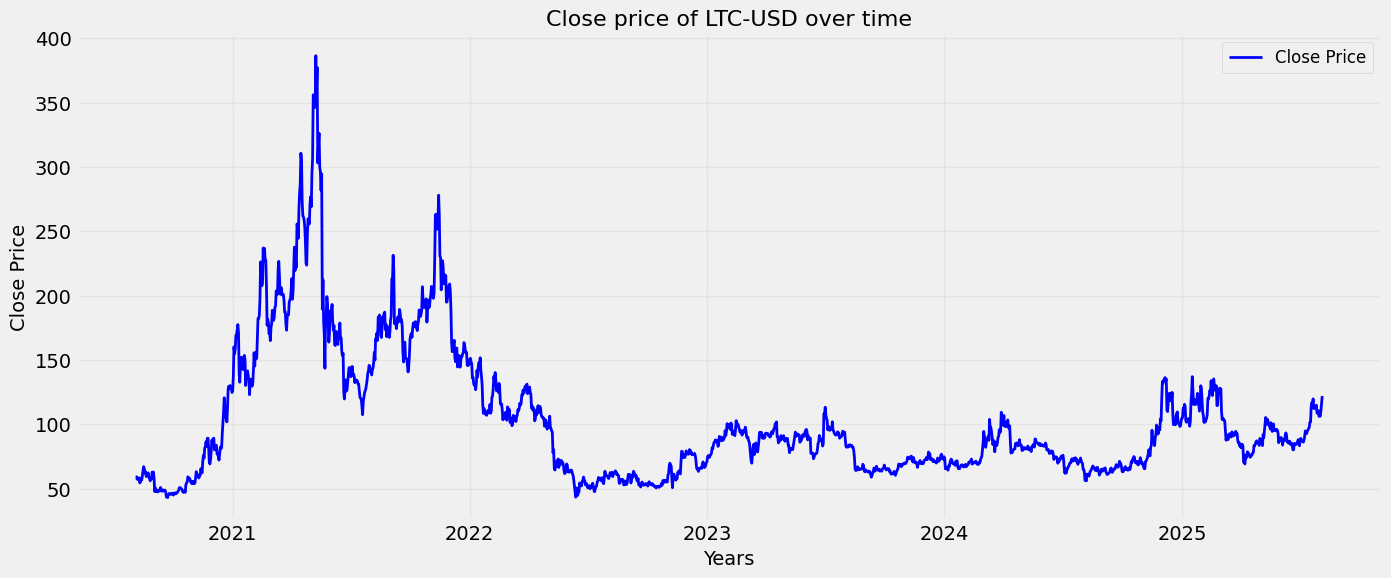

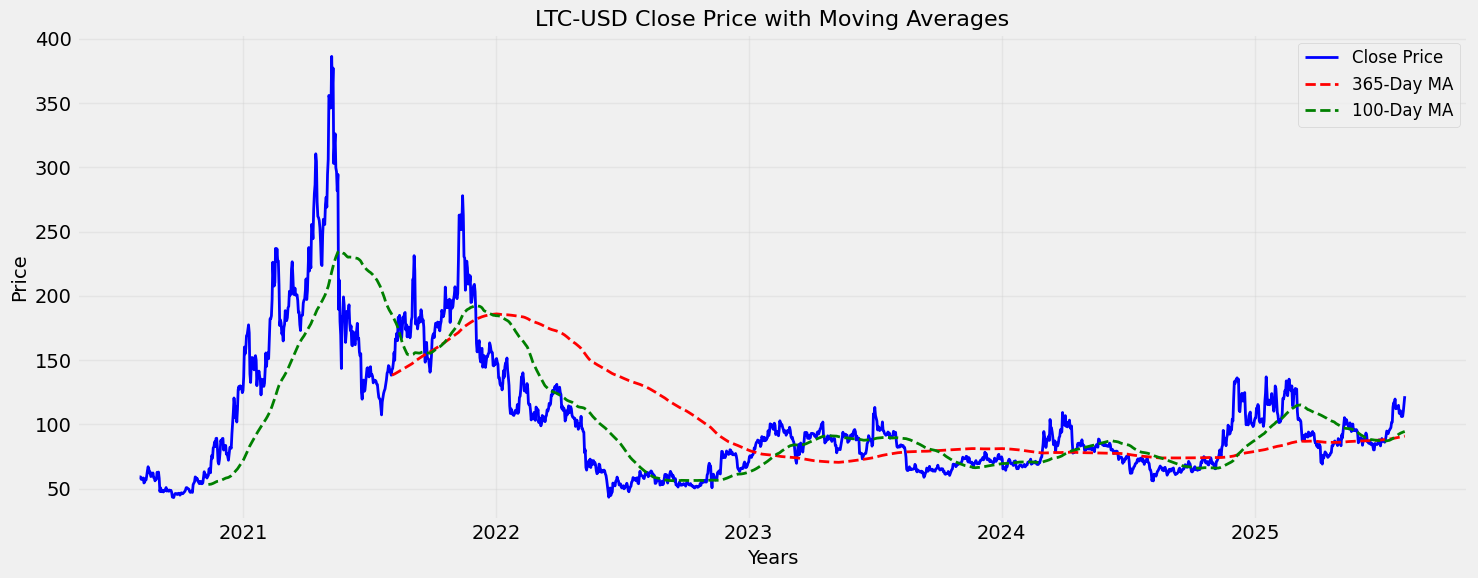

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 94ms/step


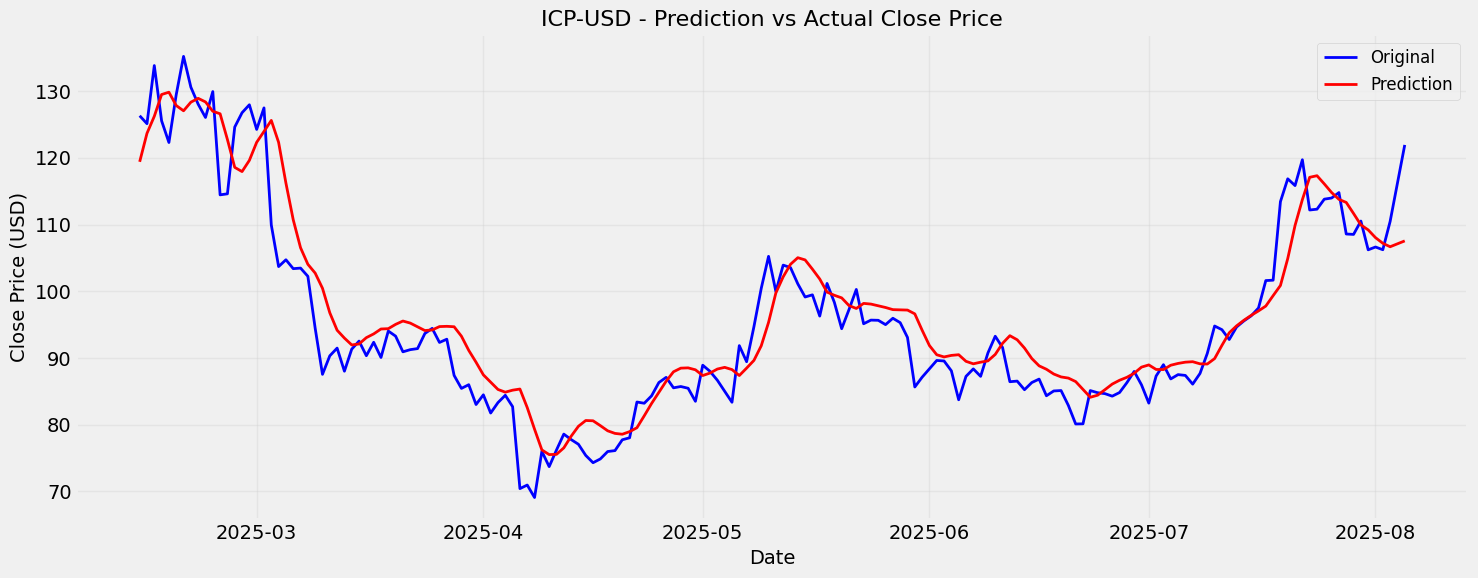


--- BCH-USD ---


[*********************100%***********************]  1 of 1 completed


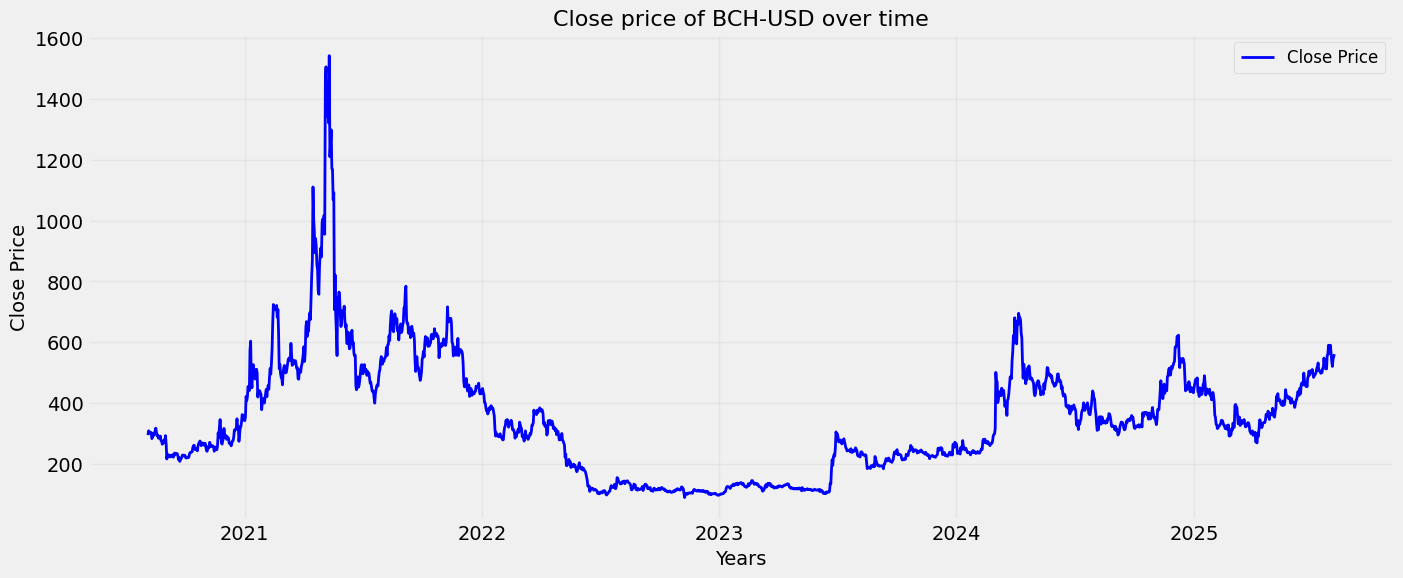

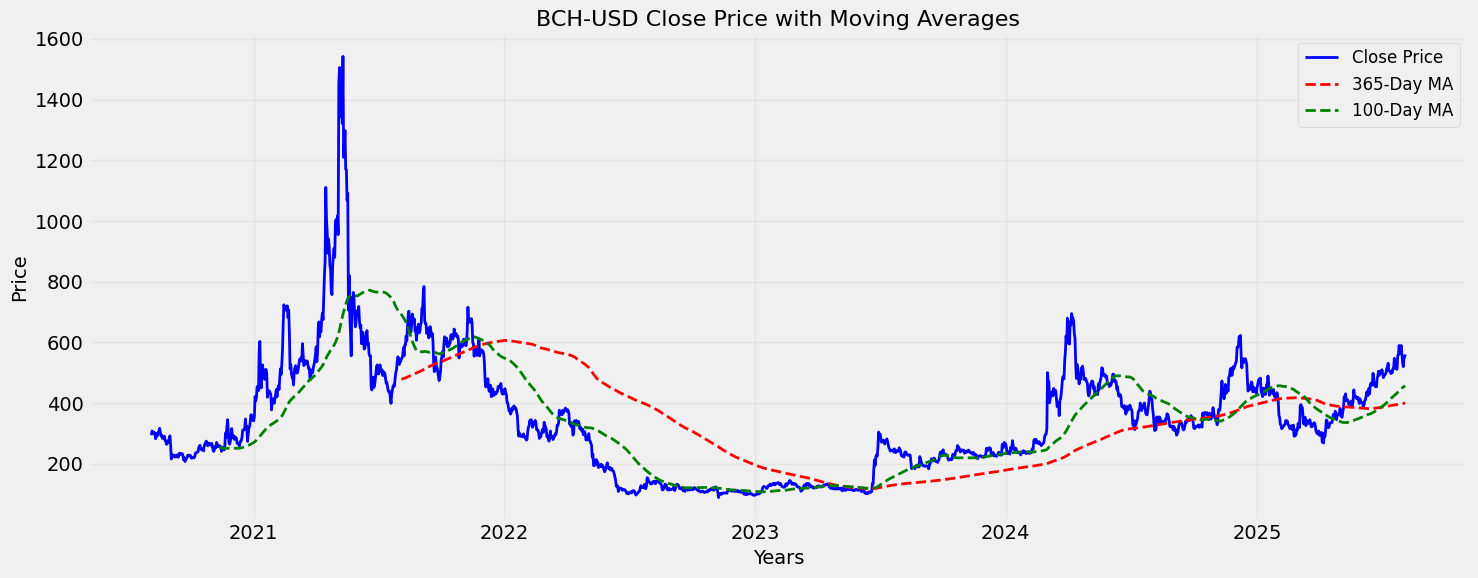

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 150ms/step


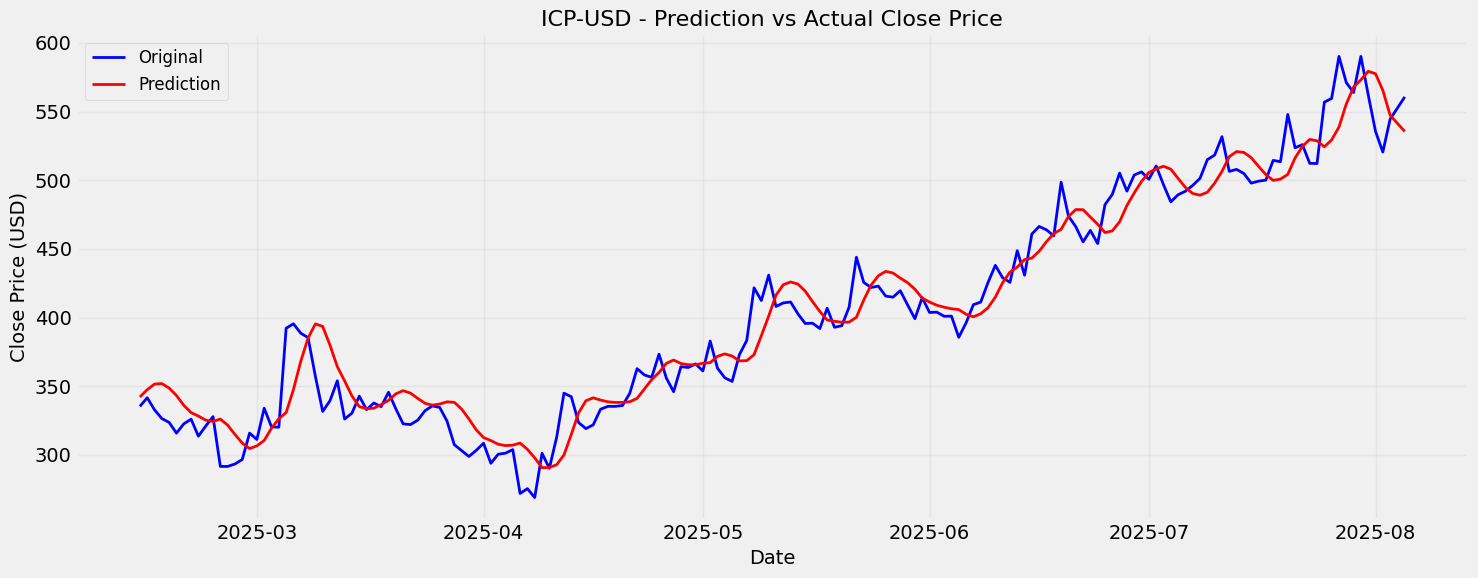


--- XLM-USD ---


[*********************100%***********************]  1 of 1 completed


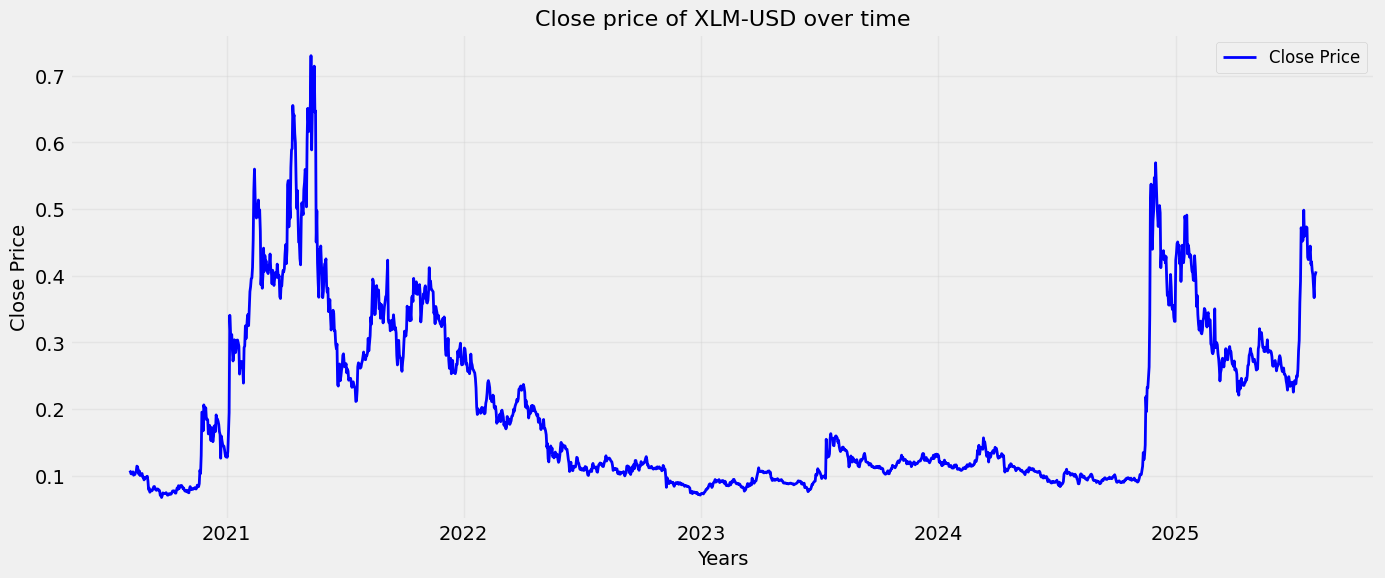

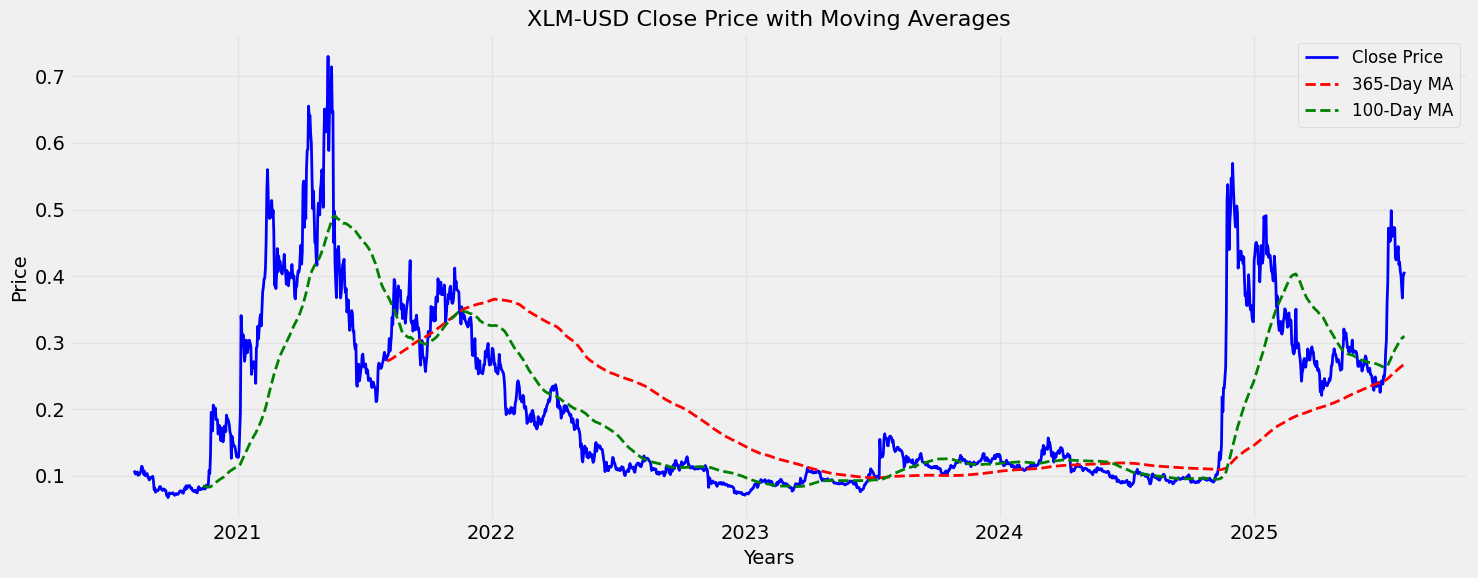

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step


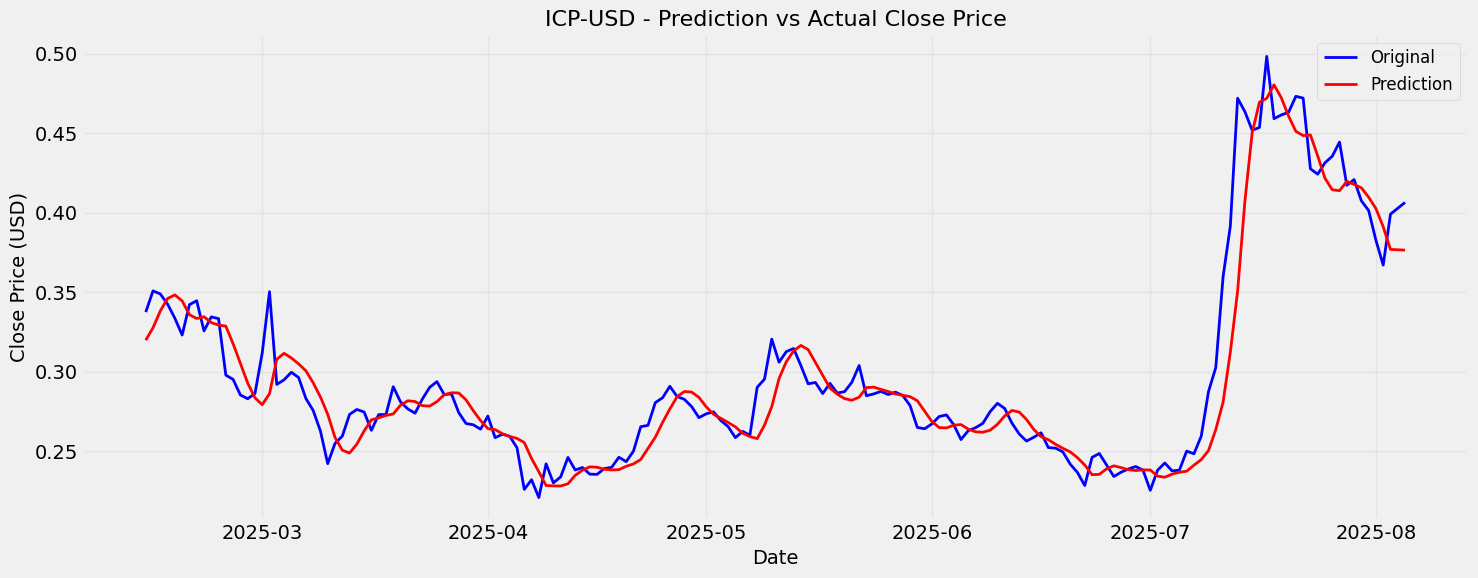


--- ATOM-USD ---


[*********************100%***********************]  1 of 1 completed


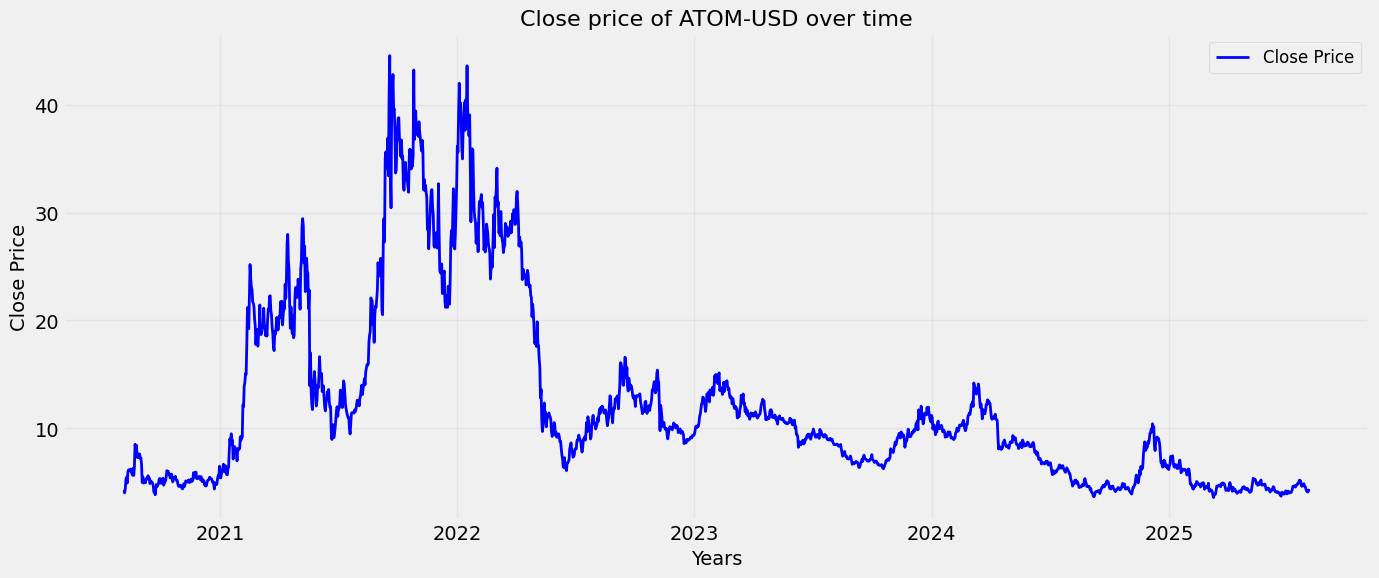

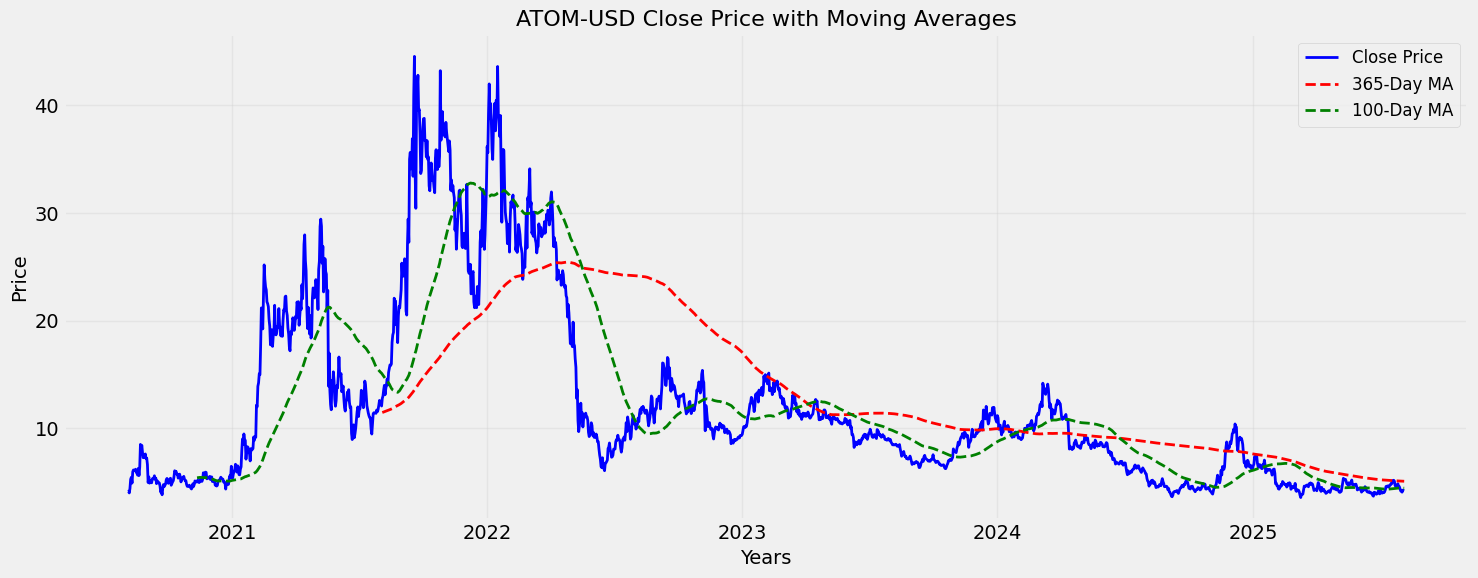

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 110ms/step


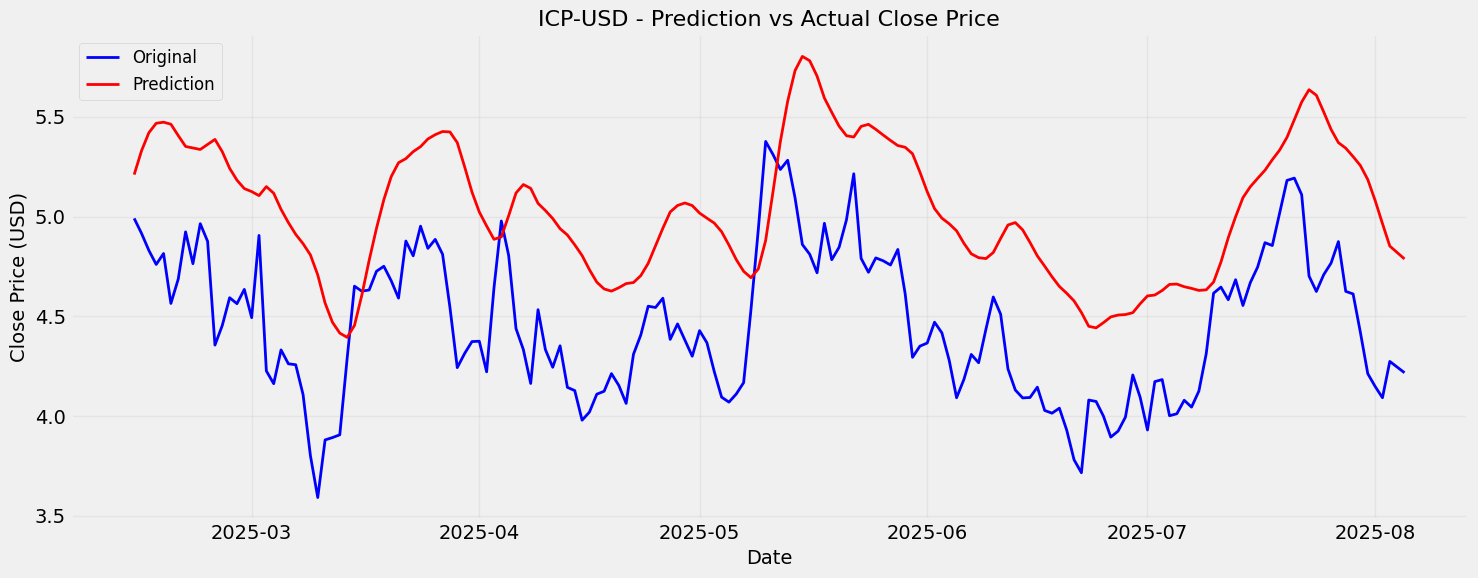


--- HBAR-USD ---


[*********************100%***********************]  1 of 1 completed


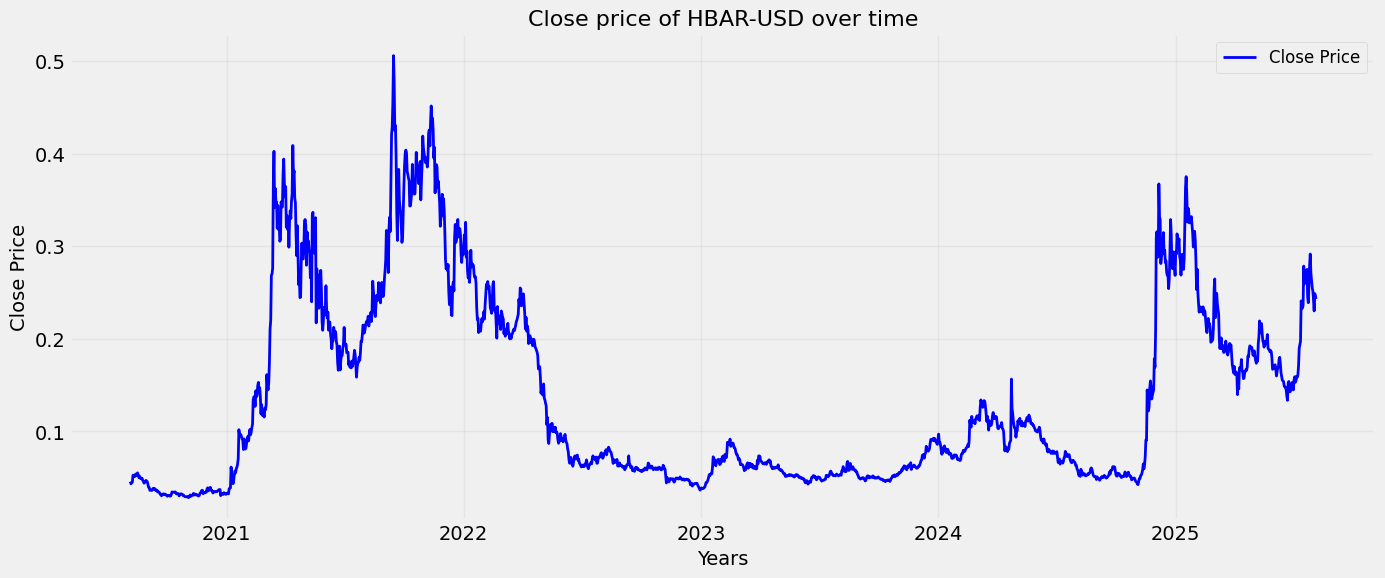

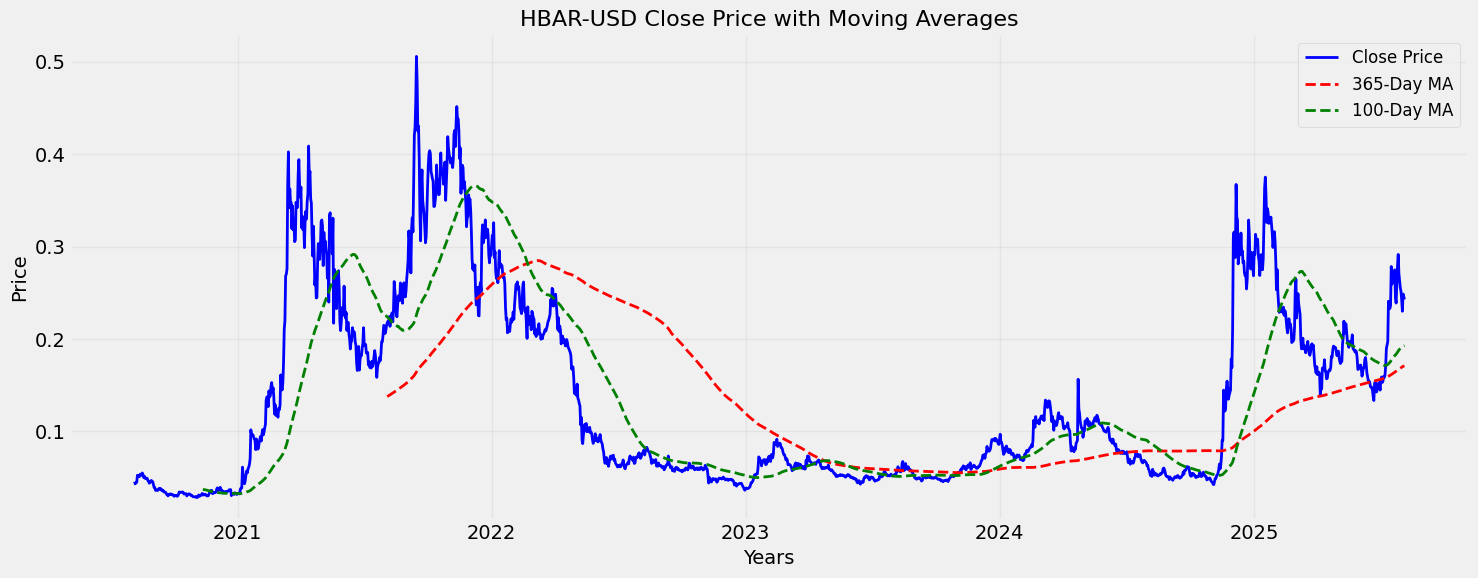

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 102ms/step


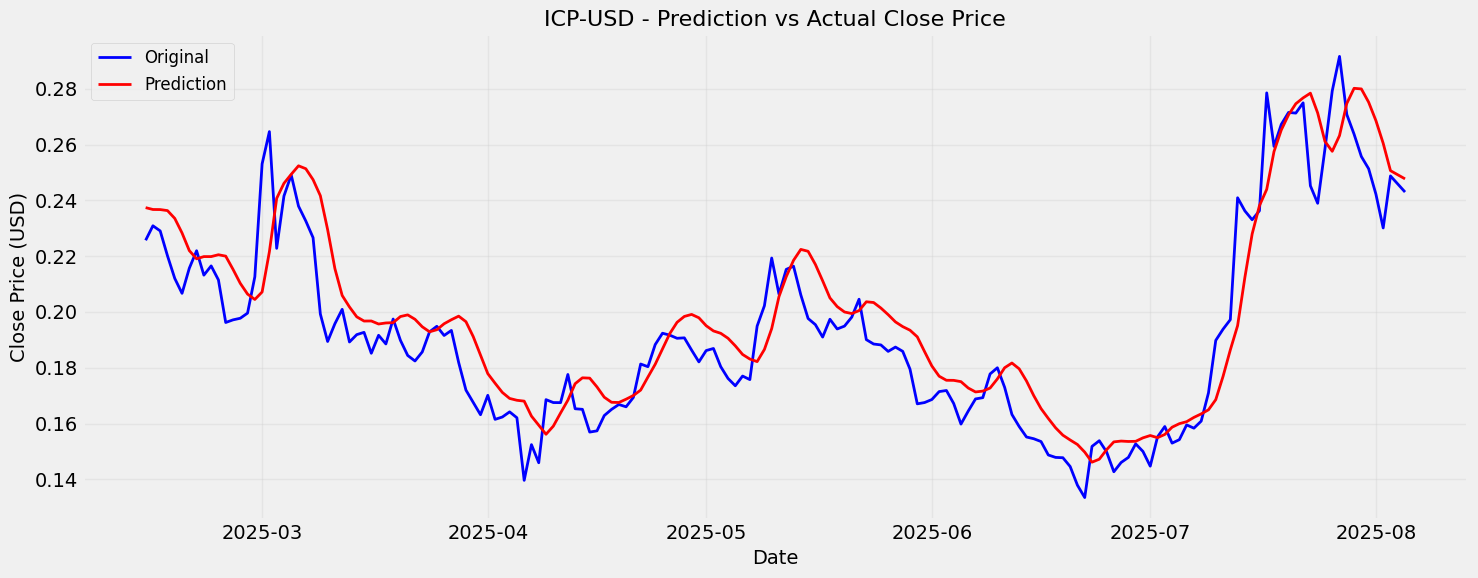


--- ETC-USD ---


[*********************100%***********************]  1 of 1 completed


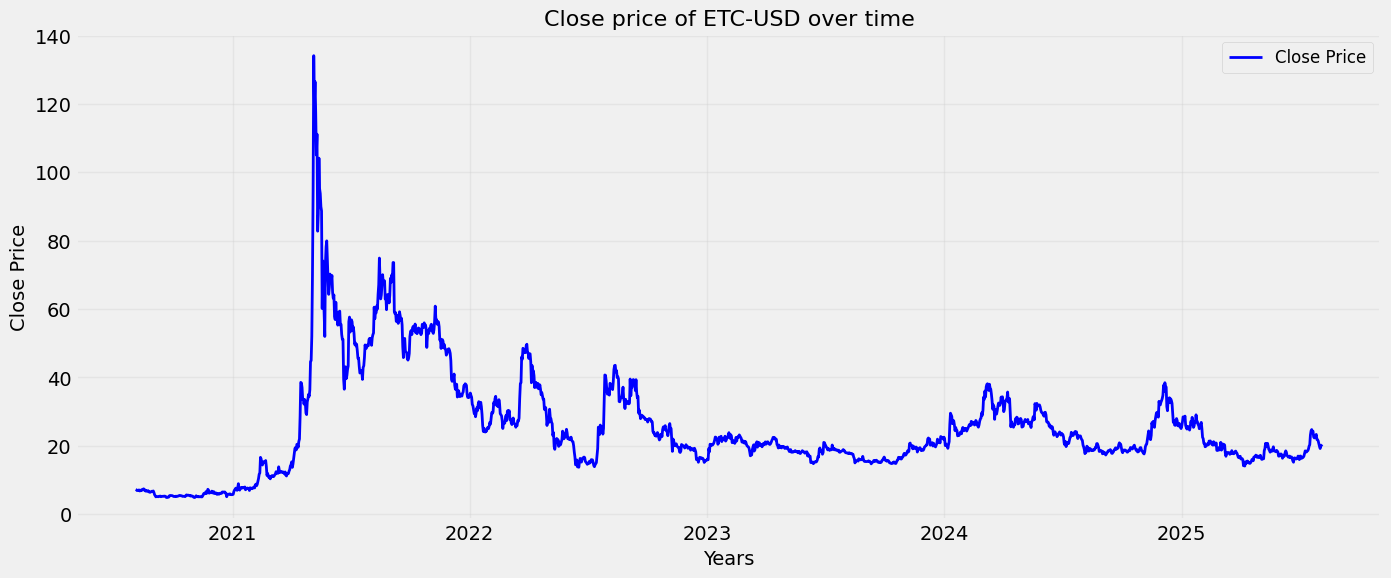

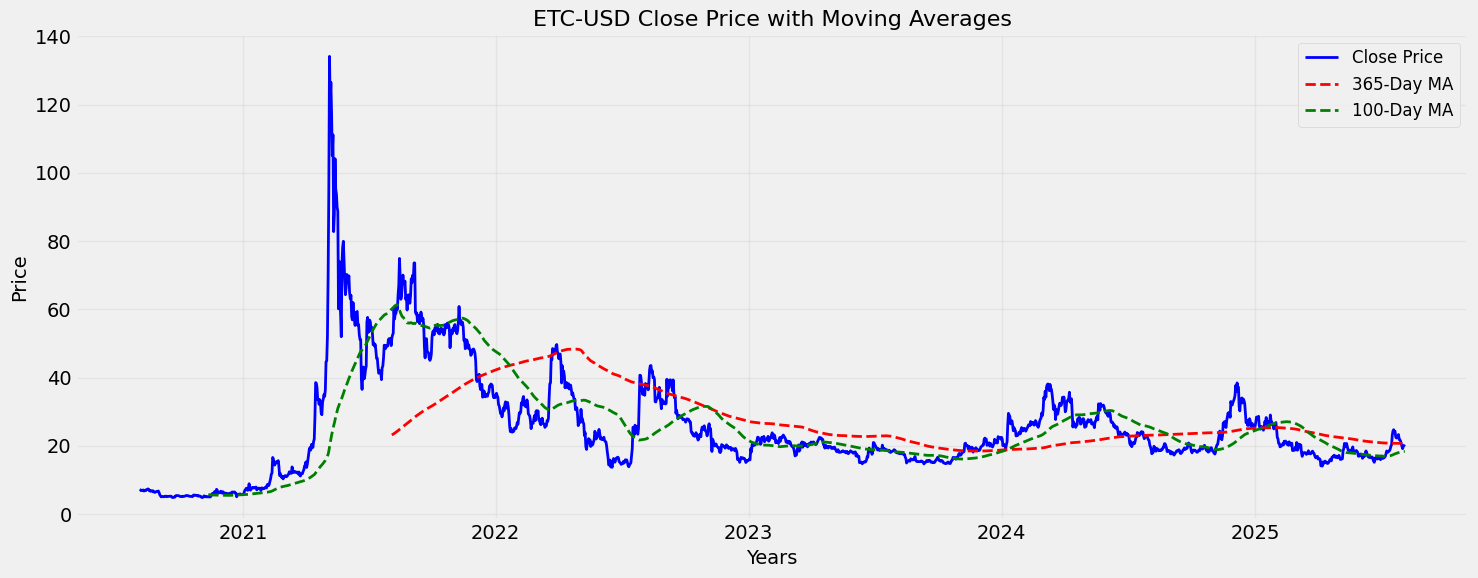

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 108ms/step


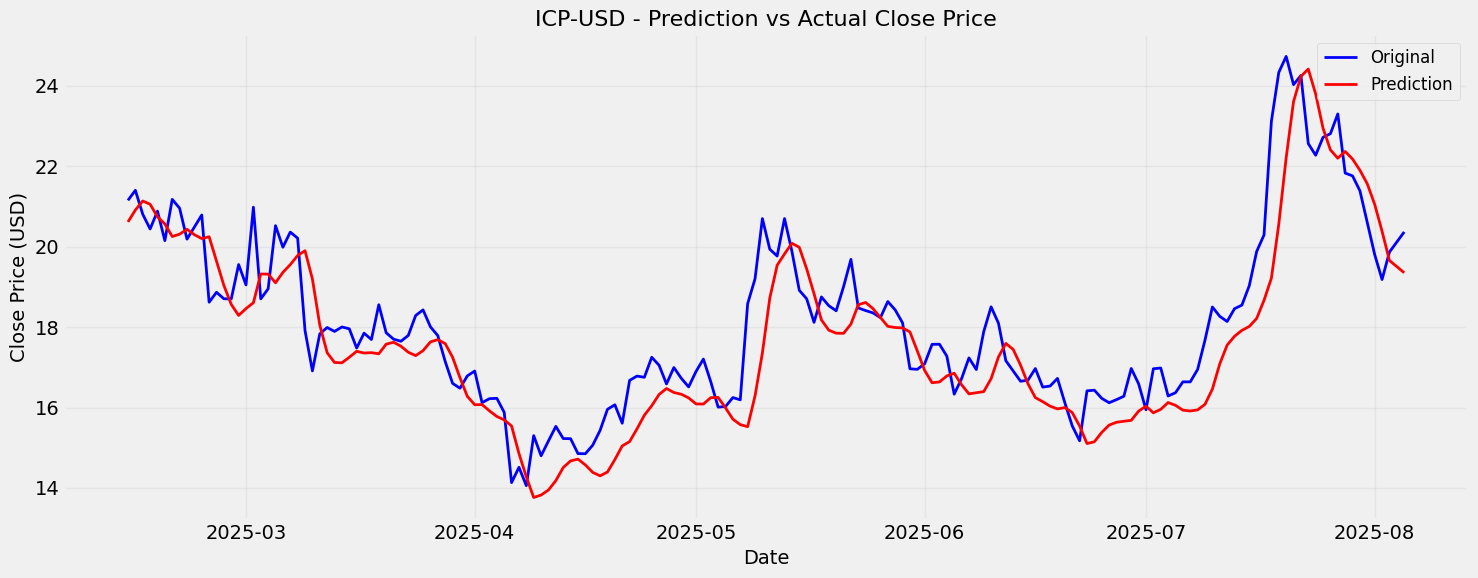


--- FIL-USD ---


[*********************100%***********************]  1 of 1 completed


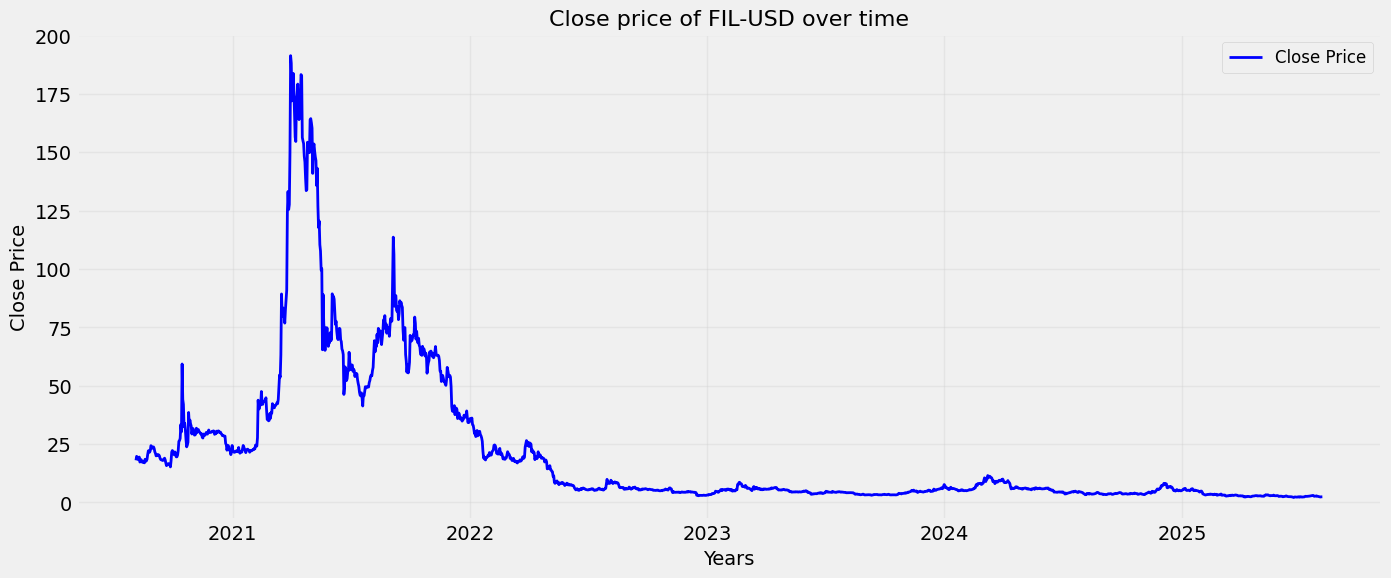

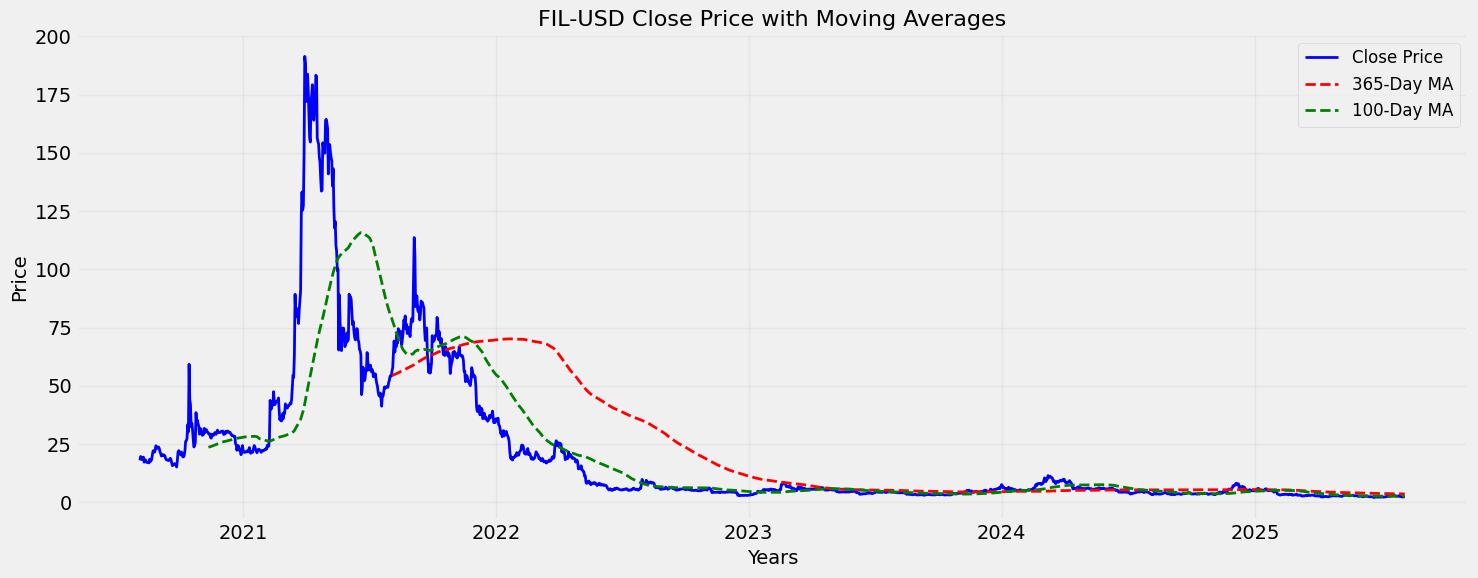

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step


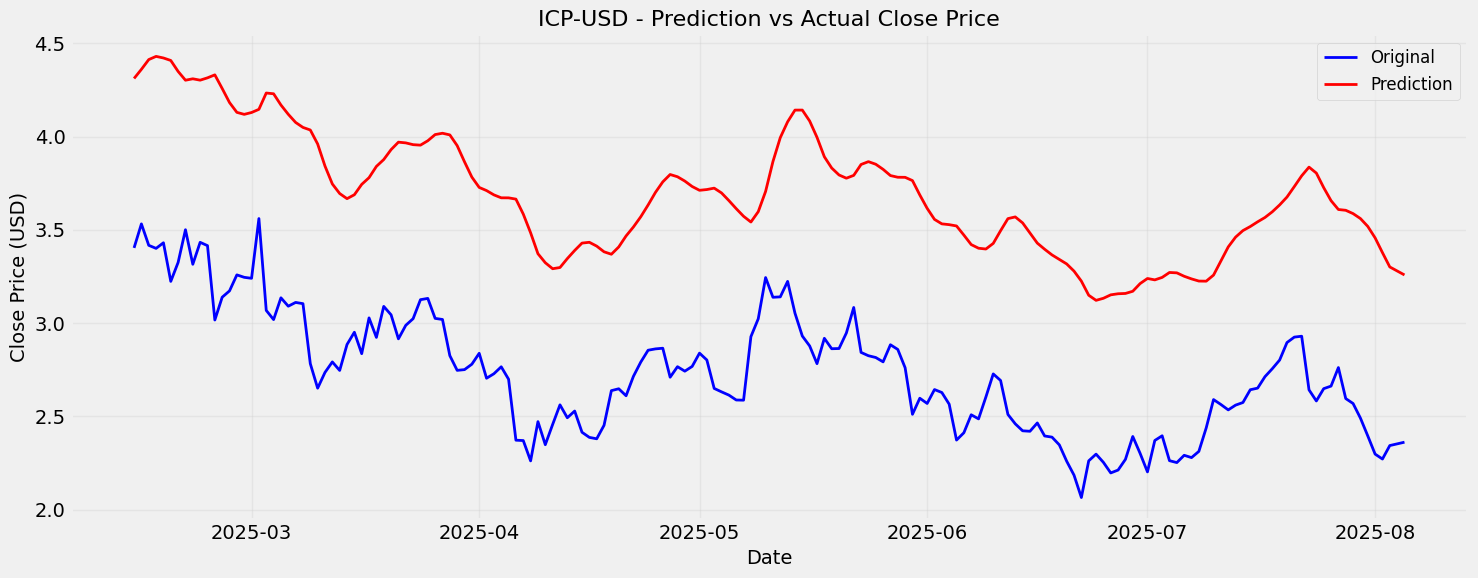


--- ICP-USD ---


[*********************100%***********************]  1 of 1 completed


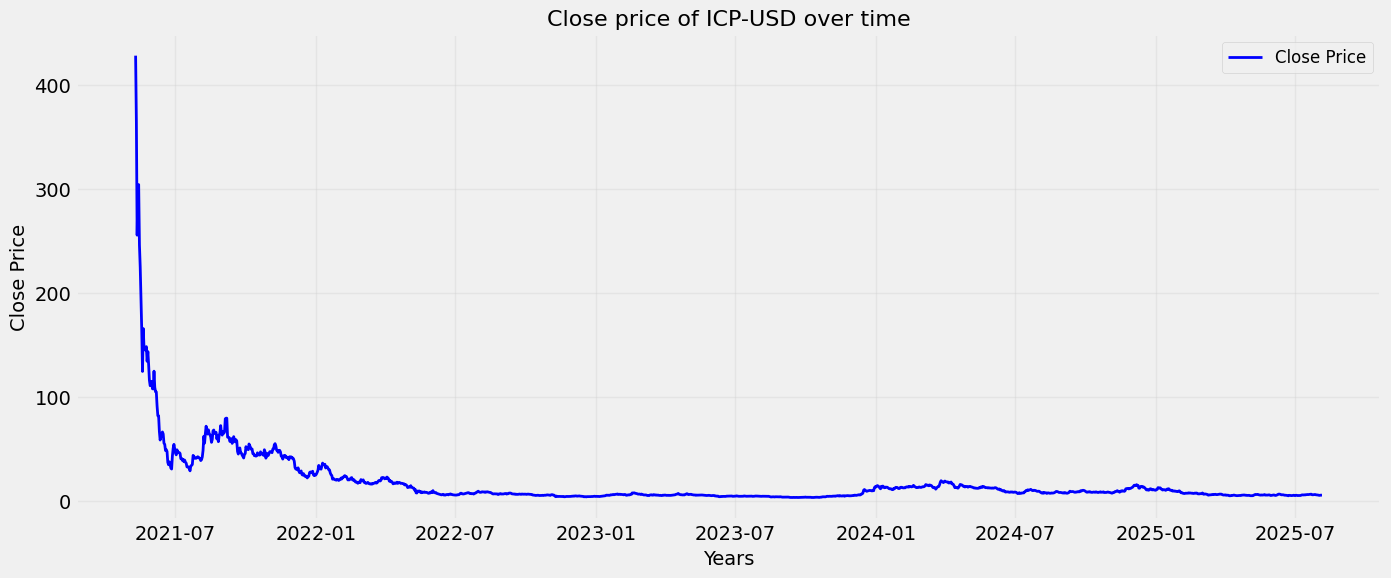

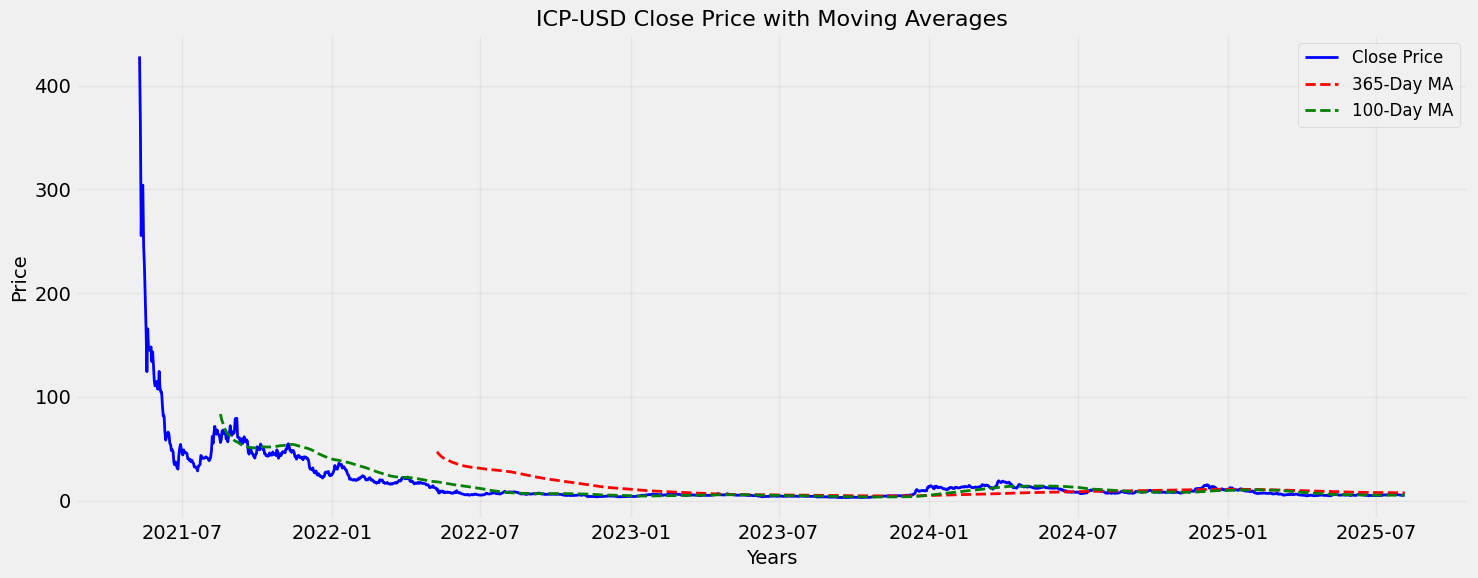

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 109ms/step


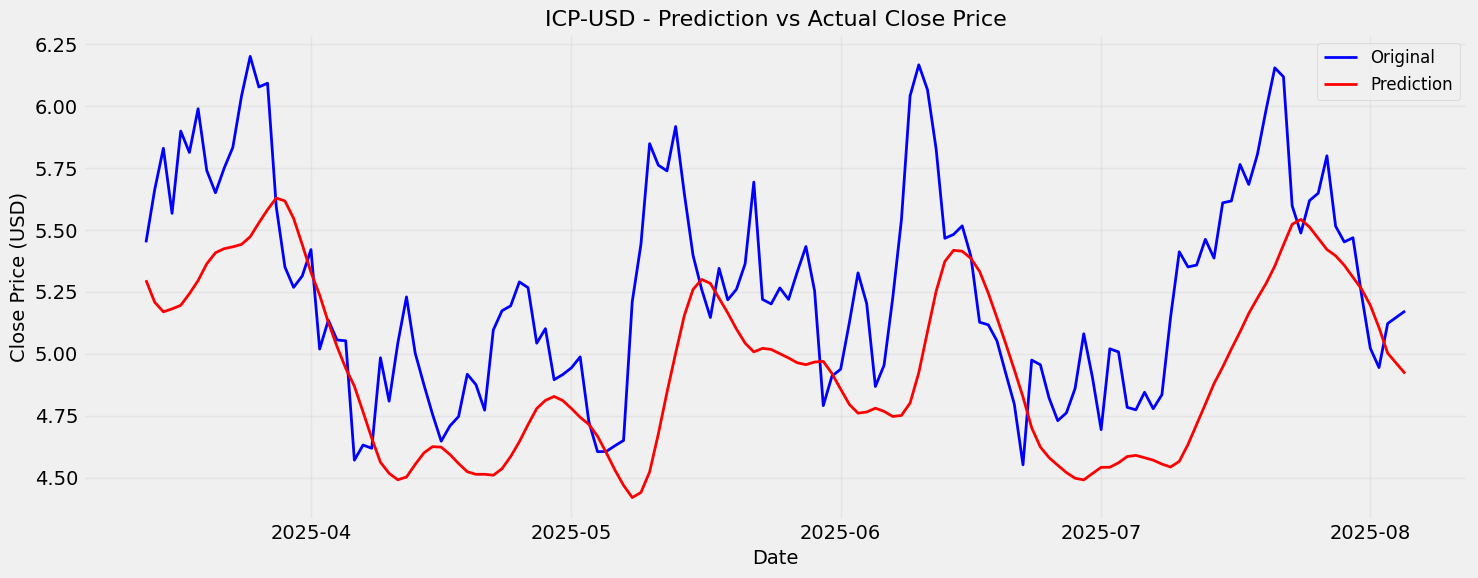

In [75]:
for symbol in cryptos:
    print(f"\n--- {symbol} ---")
    stock_data = yf.download(symbol, start=start, end=end)
    if stock_data.empty:
        print("No data found.")
        continue
    closing_price = stock_data[['Close']].dropna()
    fig, ax = plt.subplots(figsize=(15, 6))
    ax.plot(closing_price.index, closing_price['Close'], label='Close Price', color='blue', linewidth=2)
    ax.set_title(f"Close price of {symbol} over time", fontsize=16)
    ax.set_xlabel("Years", fontsize=14)
    ax.set_ylabel("Close Price", fontsize=14)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=12)
    plt.show()

    closing_price['MA_365'] = closing_price['Close'].rolling(window=365).mean()
    closing_price['MA_100'] = closing_price['Close'].rolling(window=100).mean()
    plt.figure(figsize=(15, 6))
    plt.plot(closing_price.index, closing_price['Close'], label='Close Price', color='blue', linewidth=2)
    plt.plot(closing_price.index, closing_price['MA_365'], label='365-Day MA', color='red', linestyle="--", linewidth=2)
    plt.plot(closing_price.index, closing_price['MA_100'], label='100-Day MA', color='green', linestyle="--", linewidth=2)
    plt.title(f"{symbol} Close Price with Moving Averages", fontsize=16)
    plt.xlabel("Years", fontsize=14)
    plt.ylabel("Price", fontsize=14)
    plt.grid(alpha=0.3)
    plt.legend(fontsize=12)
    plt.tight_layout()
    plt.show() 

    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled_data = scaler.fit_transform(closing_price[['Close']].values)

    x_data = []
    y_data = []
    base_days = 100
    for i in range(base_days, len(scaled_data)):
        x_data.append(scaled_data[i - base_days:i])
        y_data.append(scaled_data[i])
    
    x_data = np.array(x_data)
    y_data = np.array(y_data)

    x_data = x_data.reshape(x_data.shape[0], x_data.shape[1], 1)

    train_size = int(len(x_data) * 0.9)
    x_train, y_train = x_data[:train_size], y_data[:train_size]
    x_test, y_test = x_data[train_size:], y_data[train_size:]

    model = Sequential([
        LSTM(128, return_sequences=True, input_shape=(x_train.shape[1], 1)),
        LSTM(64, return_sequences=False),
        Dense(25),
        Dense(1)
    ])

    model.compile(optimizer='adam', loss='mean_squared_error')
    model.fit(x_train, y_train, batch_size=32, epochs=10, verbose=0)

    predictions = model.predict(x_test)

    inv_predictions = scaler.inverse_transform(predictions)
    inv_y_test = scaler.inverse_transform(y_test)

    plotting_data = pd.DataFrame({
        'Original': inv_y_test.flatten(),
        'Prediction': inv_predictions.flatten(),
    }, index=closing_price.index[train_size + base_days:])



    plt.figure(figsize=(15, 6))
    plt.plot(plotting_data.index, plotting_data['Original'], label='Original', color='blue', linewidth=2)
    plt.plot(plotting_data.index, plotting_data['Prediction'], label='Prediction', color='red', linewidth=2)
    plt.title(f"{coin} - Prediction vs Actual Close Price", fontsize=16)
    plt.xlabel("Date", fontsize=14)
    plt.ylabel("Close Price (USD)", fontsize=14)
    plt.grid(alpha=0.3)
    plt.legend(fontsize=12)
    plt.tight_layout()
    plt.show()

